# VQE with classical shadows — the measurement cost of a variational algorithm

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 11 — Variational quantum circuits*

## 1. Introduction and motivation

[42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb)
treated the energy $E(\boldsymbol\theta)=\langle\psi(\boldsymbol\theta)\vert H\vert\psi(\boldsymbol\theta)\rangle$ as a
number that is simply available. On a simulator it is: one einsum per Hamiltonian term. On a quantum computer it is
not available at all. A quantum computer can only prepare a state and measure qubits, and a measurement returns one
bit per qubit drawn from the Born distribution. Every expectation value has to be **estimated** from repetitions, and
the number of repetitions is what a real experiment pays for.

That cost is the subject of this notebook. A VQE iteration with a parameter-shift gradient needs $2n$ energy
evaluations; each energy is a sum of $O(N)$ (for a spin chain) or $O(N^4)$ (for a molecule) Pauli terms; each term
needs enough shots to be resolved. For molecular Hamiltonians the number of measurements is one of the dominant
costs of the algorithm, and reducing it is an active field of its own (Tilly *et al.*, 2022, review the strategies).

Three strategies are compared here, all on the same Hamiltonian and the same state:

1. **term by term** — measure each Pauli string in its own experiment;
2. **qubit-wise-commuting grouping** — collect terms that can be read off from the same measurement setting and
   measure each group once (Verteletskyi, Yen and Izmaylov, 2020);
3. **classical shadows** — measure every qubit in a *random* Pauli basis, store the record, and estimate any
   observable afterwards (Huang, Kueng and Preskill, 2020), as built in
   [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb).

The comparison is made at a **fixed total number of shots**, the quantity an experiment pays for, and each
deterministic strategy is also given its optimal split of those shots. We then put shadow-estimated energies inside
the optimisation loop and study a second effect: what a noisy cost function does to the reported *answer*, in
addition to what it does to the convergence.

**Road map.** Section 3 counts terms and measurement settings and derives the minimum number of settings for a
nearest-neighbour chain. Section 4 derives the variance of the energy estimator for each strategy at fixed budget,
including the covariances between terms measured in the same shot and the optimal split of the shots. Section 5
prepares the state to be measured with the VQE of notebook 42. Section 6 checks all three predictions against
simulation. Section 7 estimates the six observables of notebook 42's panel (33 Pauli strings) from one shadow data
set. Section 8 puts shadow energies inside an SPSA loop and measures accuracy against snapshot budget. Section 9
derives and measures the selection bias that noisy costs create. Section 10 is a remark on derandomisation.
Section 11 is the final characterisation of the converged state with bootstrap error bars.

### What you will learn

*Physics*

* why two Pauli observables can be read off from the same single-qubit measurement setting if and only if they
  agree qubit by qubit, and the derivation of how many settings a nearest-neighbour XXZ chain therefore needs;
* how the covariance between terms measured in the same shot enters the variance, and when it matters (for the
  state studied here it more than triples the variance of one of the three settings);
* what a variational energy estimated from randomised measurements costs.

*Numerical methods*

* the exact single-snapshot covariance of two Pauli estimators under random Pauli bases, and its verification;
* why selecting the best of several noisy cost values reports a number biased *below* the truth, by how much, and
  why the answer must be re-measured with an independent data set (the winner's curse);
* bootstrap error bars for non-linear functions of the same data set.

*Implementation practice*

* chunked snapshot collection, so that a `vmap` over snapshots never materialises more than a few thousand copies of
  the state;
* a shadow-based cost function that is `jit`-able and `vmap`-able, so it can be placed inside a `lax.scan` training
  loop;
* one batched Pauli estimator that turns a data set of integers into a (snapshots $\times$ observables) matrix, from
  which means, medians of means and bootstrap errors are cheap array operations.

### Prerequisites

* [24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb): the randomised
  measurement protocol, the inverse measurement channel, the single-snapshot Pauli estimator and its $3^k$ variance,
  median of means and bootstrap errors. All of that is used here and not re-derived;
* [42 — the variational quantum eigensolver](../ch11_variational_quantum_circuits/42_variational_quantum_eigensolver.ipynb):
  the VQE loop, the Hamiltonians, the observable panel and the exact references;
* [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb): SPSA with Spall gains, Adam, and the
  `lax.scan` training loop used again here;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): the Born rule and sampling bit strings;
* [11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb):
  the Lanczos ground state used as the exact reference.

**Conventions and sizes.** $N=6$ spins throughout, open chain, Pauli convention
$H=\sum_{\langle ij\rangle}(J_{xx}X_iX_j+J_{yy}Y_iY_j+J_{zz}Z_iZ_j)+h_x\sum_iX_i$. The main model is the XXZ chain
with $J_{xx}=J_{yy}=-1$, $J_{zz}=-1/2$, $h_x=1$; the XY chain ($J_{zz}=0$) appears as a control.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

From the engine we take the shadow primitives (`collect_pauli_shadows`, `shadow_estimate_pauli`), the basis
rotations `_BASIS_ROT` that define the measurement settings, `sample_bitstrings` for the deterministic protocols,
the Hamiltonian machinery and `lanczos_ground_state`. The batched shadow estimator, the chunked collector, the
median-of-means and bootstrap helpers are the ones derived in
[24 — classical shadows](../ch08_quantum_information_protocols/24_classical_shadows.ipynb); the optimiser and
training loop are those of [41 — optimisers](../ch11_variational_quantum_circuits/41_optimizers.ipynb).

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (copied from quantum_engine.py, the SmoQ.jax engine)
# Every function below is explained, with its mathematics and an independent check, in
# notebook 08b (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 13. Classical shadows (random Pauli measurements)
# ----------------------------------------------------------------------------
def collect_pauli_shadows(key, psi, n_shadows):
    """Randomised-measurement data set (Huang, Kueng, Preskill 2020).
    Each snapshot: draw a basis b_q in {X,Y,Z} for every qubit, rotate, measure all qubits once.
    Returns (bases, bits), int arrays of shape (n_shadows, N); basis code 0=X, 1=Y, 2=Z.
    JAX: one snapshot is a pure function of its key  ->  `vmap` over keys gives all snapshots in parallel;
         `rots[bases[q]]` selects the rotation with a traced index (gather), so no Python branching."""
    N = psi.ndim
    rots = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, rots[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        bits = (idx >> jnp.arange(N - 1, -1, -1)) & 1
        return bases, bits

    return jax.vmap(one)(jax.random.split(key, n_shadows))

def shadow_estimate_pauli(bases, bits, ops):
    """Estimate <P> of a Pauli string `ops` = {qubit: 'X'|'Y'|'Z'} from Pauli shadows.
        single-snapshot estimator   o = prod_{q in supp(P)}  3 * [b_q == P_q] * (-1)^{bit_q}
    (the factor 3 per qubit inverts the measurement channel; a snapshot contributes only if all its bases
    match on the support -- probability 3^{-k} -- hence variance ~ 3^k for weight-k strings).
    Returns (mean, standard error)."""
    code = {"X": 0, "Y": 1, "Z": 2}
    val = jnp.ones(bases.shape[0])
    for q, p in ops.items():
        val = val * 3.0 * (bases[:, q] == code[p]) * (1 - 2 * bits[:, q])
    return jnp.mean(val), jnp.std(val) / jnp.sqrt(val.shape[0])


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def hea_num_params(N, layers):
    """Number of angles of `hardware_efficient_ansatz`: (layers+1) rotation blocks x N qubits x 2 angles."""
    return 2 * N * (layers + 1)

def hardware_efficient_ansatz(theta, N, layers, entangler=CZ, periodic=False):
    """Hardware-efficient ansatz
        |psi(theta)> = R(theta_L) * prod_{l<L} [ ENT * R(theta_l) ] |0...0>,   R = prod_q Rz(.) Ry(.),
    ENT = a chain of CZ (or any 2-qubit gate).  `theta` is a flat vector of length 2N(L+1).
    The function is a pure map theta -> state, hence jit-able and differentiable end to end."""
    theta = theta.reshape(layers + 1, N, 2)
    psi = zero_state(N)
    for l in range(layers + 1):
        for q in range(N):
            psi = apply_gate(psi, ry(theta[l, q, 0]), [q])
            psi = apply_gate(psi, rz(theta[l, q, 1]), [q])
        if l < layers:
            for q in range(N - 1):
                psi = apply_gate(psi, entangler, [q, q + 1])
            if periodic and N > 2:
                psi = apply_gate(psi, entangler, [N - 1, 0])
    return psi

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + the helpers imported from notebooks 24, 41 and 42
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

BASIS_CHARS = "XYZ"                 # shadow basis code 0 = X, 1 = Y, 2 = Z  (engine convention)
PAULI_LETTERS = "IXYZ"              # Pauli-string digits 0 = I, 1 = X, 2 = Y, 3 = Z


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bands(hist):
    """Median and interquartile band of a batch of histories, shape (n_runs, n_steps) -> three curves."""
    h = np.asarray(hist)
    return np.percentile(h, 25, axis=0), np.median(h, axis=0), np.percentile(h, 75, axis=0)


def opt_adam(lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam as an (init, update) pair -- the optimiser interface of notebook 41."""
    def init(theta):
        return (jnp.zeros_like(theta), jnp.zeros_like(theta))

    def update(theta, state, g, k):
        m, v = state
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        return theta - lr * (m / (1 - b1 ** k)) / (jnp.sqrt(v / (1 - b2 ** k)) + eps), (m, v)

    return init, update


def train(theta0, key, grad_rule, opt, monitor, n_steps):
    """One training run compiled as a single `lax.scan` (notebook 41, Section 10)."""
    init_fn, update_fn = opt

    def body(carry, k):
        theta, state, key = carry
        key, sub = jax.random.split(key)
        g = grad_rule(theta, sub, k)
        theta, state = update_fn(theta, state, g, k)
        return (theta, state, key), monitor(theta)

    (theta, _, _), hist = lax.scan(body, (theta0, init_fn(theta0), key), jnp.arange(1, n_steps + 1))
    return theta, hist


def random_starts(n_runs, n_params, seed, scale=jnp.pi):
    """`n_runs` independent parameter vectors drawn uniformly from [-scale, scale]^n, plus one PRNG key each."""
    k1, k2 = jax.random.split(jax.random.PRNGKey(seed))
    return (jax.random.uniform(k1, (n_runs, n_params), minval=-scale, maxval=scale),
            jax.random.split(k2, n_runs))


def grad_exact(cost):
    """Exact gradient rule: reverse-mode AD, ignoring the key and the iteration counter."""
    gfn = jax.grad(cost)
    return lambda theta, key, k: gfn(theta)


_collect_jit = jax.jit(collect_pauli_shadows, static_argnums=(2,))       # cache: one compile per (N, chunk)


def collect_shadows(key, psi, n_shadows, chunk=4096):
    """M randomised-measurement snapshots of `psi`, collected in blocks (notebook 24, Step 2).

    IMPL   `collect_pauli_shadows` vmaps over keys; calling it on blocks of `chunk` keeps the batched
           intermediate (chunk x 2^N complex numbers) small. Block j uses `fold_in(key, j)`.
    COST   O(M N 2^N) time, O(chunk 2^N) memory.   Returns (bases, bits): int arrays of shape (M, N).
    """
    bs, ts, done = [], [], 0
    while done < n_shadows:
        c = min(chunk, n_shadows - done)
        b, t = _collect_jit(jax.random.fold_in(key, done), psi, c)
        bs.append(b); ts.append(t); done += c
    return jnp.concatenate(bs), jnp.concatenate(ts)


def pauli_digits(labels):
    """Pauli-string labels -> int array (K, N) with digits 0=I, 1=X, 2=Y, 3=Z."""
    return jnp.asarray([[PAULI_LETTERS.index(ch) for ch in lab] for lab in labels], dtype=jnp.int32)


@jax.jit
def snapshot_values(bases, bits, digits):
    """Single-snapshot Pauli estimates for every snapshot and every string (notebook 24, Eq. (6)).

    MATH   o_m(P) = prod_{q in supp(P)} 3 (-1)^{b_mq} [c_mq = P_q]
    IMPL   per qubit build the 4-entry lookup (1, 3s[.=X], 3s[.=Y], 3s[.=Z]) and gather each string's digit.
    COST   O(M K N), integer input only, no branching.   Returns an (M, K) real array.
    """
    Mn, N = bases.shape
    sgn = (1 - 2 * bits).astype(RDTYPE)
    out = jnp.ones((Mn, digits.shape[0]), dtype=RDTYPE)
    for q in range(N):
        tab = jnp.stack([jnp.ones(Mn, dtype=RDTYPE)]
                        + [3.0 * (bases[:, q] == p) * sgn[:, q] for p in range(3)], axis=1)
        out = out * tab[:, digits[:, q]]
    return out


def median_of_means(values, n_groups):
    """Median-of-means estimator, per column of an (M, K) array (notebook 24, Step 4)."""
    Mn, K = values.shape
    g = Mn // n_groups
    v = values[: g * n_groups].reshape(n_groups, g, K)
    return jnp.median(v.mean(axis=1), axis=0)


def bootstrap_std(key, values, n_boot=200):
    """Bootstrap standard deviation of the sample mean, per column of an (M, K) array (notebook 24, Step 4).

    IMPL   a resample is a multiplicity vector counts = zeros(M).at[idx].add(1); the resampled mean is
           counts @ values / M.  vmap over B resamples: ONE (B, M) x (M, K) matrix product.
    """
    Mn = values.shape[0]

    def one(k):
        idx = jax.random.randint(k, (Mn,), 0, Mn)
        return jnp.zeros(Mn, dtype=RDTYPE).at[idx].add(1.0)

    counts = jax.vmap(one)(jax.random.split(key, n_boot))
    return (counts @ values / Mn).std(axis=0)

## 3. The measurement problem

### 3.1 A local Hamiltonian is a sum of Pauli strings

Write the Hamiltonian in the Pauli basis,

$$H=\sum_{t=1}^{T}c_t\,P_t ,\qquad P_t=\bigotimes_{q}\sigma^{(t)}_q,\ \ \sigma\in\{\mathbb 1,X,Y,Z\} . \tag{1}$$

For the XXZ chain of Section 1 on an open chain of $N$ sites the terms are $X_iX_{i+1}$, $Y_iY_{i+1}$, $Z_iZ_{i+1}$
on each of the $N-1$ bonds and $X_i$ on each of the $N$ sites, so

$$T=3(N-1)+N=4N-3 , \tag{2}$$

which is $21$ at $N=6$. For the transverse-field Ising model only the $ZZ$ bonds and the $X$ fields survive, so
$T=2N-1$. A molecular Hamiltonian in second quantisation, after the Jordan-Wigner transformation, has
$T=O(N^4)$ terms — the reason the accounting below matters.

By linearity,

$$\langle H\rangle=\sum_tc_t\langle P_t\rangle ,$$

so the task is to estimate $T$ numbers. A quantum measurement reads each qubit in **one** basis, so
$\langle X_0X_1\rangle$ and $\langle Y_0Y_1\rangle$ cannot both be read from the same shot.

### 3.2 Strategy 1: term by term

The simplest protocol. Split the budget of $S$ shots equally, $m=S/T$ shots per term; for term $t$ rotate every qubit
of $\mathrm{supp}(P_t)$ into the eigenbasis of its Pauli factor, measure, and average the product of the $\pm1$
outcomes. Each of the $T$ experiments is independent of the others.

### 3.3 Strategy 2: qubit-wise-commuting groups

A **measurement setting** is a choice of one basis $b_q\in\{X,Y,Z\}$ per qubit. A Pauli string $P$ can be read off
from a shot taken in setting $b$ if and only if

$$\sigma^{(P)}_q\in\{\mathbb 1,\ b_q\}\quad\text{for every }q , \tag{3}$$

i.e. wherever $P$ is not the identity, the setting measured exactly that Pauli. Two strings that both satisfy Eq. (3)
for a common $b$ are called **qubit-wise commuting**; one shot then yields an unbiased estimate of *both*. Grouping
the $T$ terms into as few settings as possible is a graph-colouring problem in general (Verteletskyi, Yen and
Izmaylov, 2020), but for a nearest-neighbour chain we can solve it exactly.

**Claim.** The XXZ chain of Eq. (2) needs exactly $G=3$ settings, and the transverse-field Ising chain exactly
$G=2$.

*Lower bound.* Fix one bond $(i,i+1)$. The three terms $X_iX_{i+1}$, $Y_iY_{i+1}$, $Z_iZ_{i+1}$ require, by Eq. (3),
the pairs $(b_i,b_{i+1})=(X,X)$, $(Y,Y)$ and $(Z,Z)$ respectively. One setting fixes one pair $(b_i,b_{i+1})$ and
hence covers at most one of the three, so at least three settings are needed. For the Ising chain the terms
$Z_iZ_{i+1}$ and $X_i$ demand $b_i=Z$ and $b_i=X$, which is already two.

*Upper bound.* Three settings suffice: measure **every** qubit in $X$, then every qubit in $Y$, then every qubit in
$Z$. The all-$X$ setting delivers all $N-1$ correlators $\langle X_iX_{i+1}\rangle$ *and* all $N$ fields
$\langle X_i\rangle$ from the same shots; the all-$Y$ and all-$Z$ settings deliver the remaining bond terms. For the
Ising chain the all-$Z$ and all-$X$ settings suffice. $\square$

The number of experiments drops from $T=4N-3$ to $3$, **independently of $N$**: for a local chain grouping removes
the $N$-dependence of the setting count entirely. (Allowing general commuting sets rather than qubit-wise commuting ones can reduce the count further for
other Hamiltonians, at the price of a Clifford circuit before the measurement.)

### 3.4 Strategy 3: classical shadows

Choose the basis of every qubit **at random** from $\{X,Y,Z\}$ and record the bases and the outcome bits. Notebook 24
derived the single-snapshot estimator of a Pauli string $P$ of weight $k$:

$$\hat o(P)=\prod_{q\in\mathrm{supp}(P)}3\,(-1)^{b_q}\,\bigl[\,c_q=\sigma^{(P)}_q\,\bigr],
  \qquad\mathbb E[\hat o]=\langle P\rangle,\qquad \mathbb E[\hat o^{\,2}]=3^{k} , \tag{4}$$

where $c_q$ is the basis actually measured on qubit $q$ and $[\cdot]$ is an indicator. A snapshot contributes to $P$
only if it happened to measure the right axis on all $k$ qubits of the support — probability $3^{-k}$ — and the
factor $3^k$ compensates exactly.

The structural advantage is that the data are collected **before** anyone decides what to estimate. The structural
disadvantage is visible in Eq. (4): a weight-2 term carries a second moment of $9$ per snapshot, where a dedicated
setting carries at most $1$.

## 4. The variance of the energy estimator, at a fixed shot budget

All three strategies are unbiased, so the comparison is entirely about variance. Fix the total number of shots $S$ —
the number of times the machine is run — and compute $\mathrm{Var}(\hat E)$ for each.

### 4.1 Term by term

Term $t$ gets $m=S/T$ shots. A single shot returns the product of $\pm1$ outcomes on $\mathrm{supp}(P_t)$, a random
variable with mean $\langle P_t\rangle$ and, because its square is $1$, variance $1-\langle P_t\rangle^2$. The $T$
experiments are independent, so the variances of $c_t\hat{\langle P_t\rangle}$ add:

$$\mathrm{Var}_{\text{term}}(\hat E)=\sum_t\frac{c_t^2\bigl(1-\langle P_t\rangle^2\bigr)}{m}
  =\frac{T}{S}\sum_{t}c_t^2\bigl(1-\langle P_t\rangle^2\bigr). \tag{5}$$

The factor $T$ is the price of splitting the budget $T$ ways. Part of it can be recovered by giving the noisier terms
more shots. With $m_t$ shots for term $t$ and $a_t=\lvert c_t\rvert\sqrt{1-\langle P_t\rangle^2}$, the variance is
$\sum_ta_t^2/m_t$, to be minimised at fixed $\sum_tm_t=S$. The Cauchy-Schwarz inequality gives
$\bigl(\sum_ta_t\bigr)^2=\bigl(\sum_t\tfrac{a_t}{\sqrt{m_t}}\sqrt{m_t}\bigr)^2\le\bigl(\sum_ta_t^2/m_t\bigr)S$,
with equality for $m_t\propto a_t$, so the optimal (Neyman) allocation achieves

$$\mathrm{Var}^{\text{opt}}_{\text{term}}(\hat E)=\frac1S\Bigl(\sum_t\lvert c_t\rvert\sqrt{1-\langle P_t\rangle^2}\Bigr)^2
  \;\le\;\mathrm{Var}_{\text{term}}(\hat E) . \tag{5a}$$

The allocation needs the $\langle P_t\rangle$, which are not known in advance; in practice they are taken from a
pilot run or from the previous VQE iteration. Equation (5a) is the fair benchmark for the term-by-term protocol.

### 4.2 Grouped settings

With $G$ settings and $S/G$ shots each, one shot in setting $g$ yields *simultaneously* the $\pm1$ values $p_t$ of
every term in that group, so the natural per-shot random variable is the partial energy

$$A_g=\sum_{t\in g}c_t\,p_t .$$

The estimator is $\hat E=\sum_g\bar A_g$ with $\bar A_g$ the mean over the $S/G$ shots of setting $g$, hence

$$\mathrm{Var}_{\text{group}}(\hat E)=\frac{G}{S}\sum_g\mathrm{Var}(A_g),\qquad
  \mathrm{Var}(A_g)=\sum_{t,t'\in g}c_tc_{t'}\Bigl(\langle P_tP_{t'}\rangle-\langle P_t\rangle\langle P_{t'}\rangle
  \Bigr). \tag{6}$$

The off-diagonal terms of Eq. (6) are **covariances between observables measured in the same shot**. They can have
either sign: negative covariances make grouping win by more than the factor $T/G$ that the counting suggests,
positive ones by less. The same Cauchy-Schwarz argument as for Eq. (5a), with $S_g\propto\sqrt{\mathrm{Var}(A_g)}$
shots for setting $g$, gives the optimally allocated grouped variance

$$\mathrm{Var}^{\text{opt}}_{\text{group}}(\hat E)=\frac1S\Bigl(\sum_g\sqrt{\mathrm{Var}(A_g)}\Bigr)^2 . \tag{6a}$$

Because the members of one group are qubit-wise commuting, every product $P_tP_{t'}$ is again a Pauli string (equal
single-qubit factors multiply to the identity), so Eq. (6) is exactly computable.

### 4.3 Classical shadows

Each snapshot yields one estimate of the whole energy,

$$\hat e_m=\sum_tc_t\,\hat o_m(P_t) ,$$

and the $S$ snapshots are independent, so $\mathrm{Var}_{\text{shadow}}(\hat E)=\mathrm{Var}(\hat e)/S$ with

$$\mathrm{Var}(\hat e)=\sum_{t,t'}c_tc_{t'}\,\mathrm{Cov}\bigl(\hat o(P_t),\hat o(P_{t'})\bigr). \tag{7}$$

The covariance can be evaluated in closed form. Let $I=\mathrm{supp}(P_t)\cap\mathrm{supp}(P_{t'})$ and
$U=\mathrm{supp}(P_t)\cup\mathrm{supp}(P_{t'})$.

* If $P_t$ and $P_{t'}$ **disagree** on some qubit of $I$, no single snapshot can match both, so
  $\hat o(P_t)\hat o(P_{t'})=0$ identically and $\mathrm{Cov}=-\langle P_t\rangle\langle P_{t'}\rangle$.
* If they **agree** on $I$, then from Eq. (4)

$$\hat o(P_t)\,\hat o(P_{t'})=3^{k_t+k_{t'}}\prod_{q\in U}\bigl[c_q=\sigma_q\bigr]
  \prod_{q\in U\setminus I}(-1)^{b_q},$$

  because on $I$ the two signs $(-1)^{b_q}$ appear twice and square to one, while the indicator is idempotent. The
  bases are uniform and independent, so the probability that all $\lvert U\rvert$ of them match is $3^{-\lvert U\rvert}$,
  and conditioned on that the remaining signs average to $\langle P_tP_{t'}\rangle$ (the product string is supported
  exactly on $U\setminus I$). With $k_t+k_{t'}=\lvert U\rvert+\lvert I\rvert$,

$$\mathbb E\bigl[\hat o(P_t)\hat o(P_{t'})\bigr]=3^{\lvert I\rvert}\,\langle P_tP_{t'}\rangle
  \qquad\Longrightarrow\qquad
  \mathrm{Cov}=3^{\lvert I\rvert}\langle P_tP_{t'}\rangle-\langle P_t\rangle\langle P_{t'}\rangle . \tag{8}$$

Setting $t=t'$ gives $\lvert I\rvert=k$ and $\langle P^2\rangle=1$, reproducing
$\mathrm{Var}(\hat o)=3^{k}-\langle P\rangle^2$ — Eq. (7) of notebook 24. Equation (8) is the new ingredient, and it
says something physical: two terms that overlap on $\lvert I\rvert$ qubits and agree there are **positively**
correlated by a factor $3^{\lvert I\rvert}$, so on a chain, where neighbouring bond terms share a site, the
off-diagonal part of Eq. (7) is comparable to the diagonal one.

### 4.4 What to expect

Counting alone suggests $\mathrm{Var}_{\text{term}}:\mathrm{Var}_{\text{group}}\approx T:G$, i.e. $21:3$ here, and
puts shadows near term-by-term because of the $3^k$ of Eq. (4). The covariances of Eqs. (6) and (8) can move both.
We now compute all three numbers exactly and check them against simulation.

## 5. The state to be measured: a VQE ground state

The scenario is the realistic one: a variational circuit has been trained (notebook 42) and we now want to know what
it produced. We reproduce that first step compactly — hardware-efficient ansatz, exact gradients, Adam, several
random restarts — and keep the best run. Everything measured afterwards is measured on *that* state, whose exact
properties we know but pretend not to.

In [4]:
# ==============================================================================
# STEP 1: the model, its exact ground state, and a trained variational state
# ==============================================================================
N_SITES = 6
MODELS = {"XXZ": (-1.0, -1.0, -0.5, 1.0),        # (Jxx, Jyy, Jzz, hx)
          "XY": (-1.0, -1.0, 0.0, 1.0)}
MODEL = "XXZ"
L_ANS, LR_ANS, R_ANS, T_ANS = 3, 0.4, 8, 250


def model_terms(N, c):
    """H = sum_i (c0 XX + c1 YY + c2 ZZ)_{i,i+1} + c3 sum_i X_i, as a list of local terms (c may be traced)."""
    bond = c[0] * XX + c[1] * YY + c[2] * ZZ
    return [((i, i + 1), bond) for i in range(N - 1)] + [((i,), c[3] * X) for i in range(N)]


c_model = jnp.asarray(MODELS[MODEL], dtype=RDTYPE)
terms = model_terms(N_SITES, c_model)
E0, psi_exact = lanczos_ground_state(terms, N_SITES)
psi_exact = psi_exact / jnp.linalg.norm(psi_exact)
E0_dense = float(np.min(np.linalg.eigvalsh(np.asarray(dense_hamiltonian(terms, N_SITES)))))
print(f"{MODEL} chain, N={N_SITES}, couplings (Jxx, Jyy, Jzz, hx) = {MODELS[MODEL]}")
print(f"  exact ground energy: {E0:.9f} (Lanczos) vs {E0_dense:.9f} (dense eigh), "
      f"difference {abs(E0 - E0_dense):.1e}")
assert abs(E0 - E0_dense) < 1e-8

n_ans = hea_num_params(N_SITES, L_ANS)
cost_exact = jax.jit(lambda t: energy(terms, hardware_efficient_ansatz(t, N_SITES, L_ANS)))
th0, ks0 = random_starts(R_ANS, n_ans, seed=101)
t0 = time.perf_counter()
th_fin, hist_vqe = jax.block_until_ready(jax.jit(jax.vmap(lambda t, k: train(
    t, k, grad_exact(cost_exact), opt_adam(LR_ANS), lambda z: cost_exact(z) - E0, T_ANS)))(th0, ks0))
hist_vqe = np.asarray(hist_vqe)
i_best = int(np.argmin(hist_vqe[:, -1]))
theta_vqe = th_fin[i_best]
psi_vqe = hardware_efficient_ansatz(theta_vqe, N_SITES, L_ANS)
E_vqe = float(energy(terms, psi_vqe))
print(f"\nVQE: {R_ANS} restarts x {T_ANS} Adam iterations, L={L_ANS}, n={n_ans} angles "
      f"({time.perf_counter() - t0:.1f} s)")
print(f"  median final E - E_0 = {np.median(hist_vqe[:, -1]):.5f},  best = {hist_vqe[:, -1].min():.5f}")
print(f"  the state we will now measure:  E = {E_vqe:.6f}  (E - E_0 = {E_vqe - E0:.3e}),  "
      f"F = {float(fidelity_pure(psi_exact, psi_vqe)):.5f},  "
      f"S_half = {float(entanglement_entropy(psi_vqe, range(N_SITES // 2))):.4f}")

XXZ chain, N=6, couplings (Jxx, Jyy, Jzz, hx) = (-1.0, -1.0, -0.5, 1.0)
  exact ground energy: -11.192715190 (Lanczos) vs -11.192715190 (dense eigh), difference 1.6e-14



VQE: 8 restarts x 250 Adam iterations, L=3, n=48 angles (3.3 s)
  median final E - E_0 = 0.01742,  best = 0.00791


  the state we will now measure:  E = -11.184801  (E - E_0 = 7.914e-03),  F = 0.99904,  S_half = 0.0393


In [5]:
# ==============================================================================
# STEP 2: the Hamiltonian as a list of (coefficient, Pauli-string label) pairs
# ==============================================================================
def hamiltonian_pauli_list(N, c):
    """Eq. (1) for the chain: returns (labels, coefficients) with labels like 'IXXIII'.

    Order: the three bond terms of every bond, then the N field terms.
    """
    labels, coeffs = [], []
    for i in range(N - 1):
        for p, cc in zip("XYZ", (c[0], c[1], c[2])):
            if cc != 0.0:
                labels.append("I" * i + p + p + "I" * (N - i - 2)); coeffs.append(float(cc))
    for i in range(N):
        if c[3] != 0.0:
            labels.append("I" * i + "X" + "I" * (N - i - 1)); coeffs.append(float(c[3]))
    return labels, np.array(coeffs)


LABELS, COEFFS = hamiltonian_pauli_list(N_SITES, MODELS[MODEL])
T_TERMS = len(LABELS)
DIGITS = pauli_digits(LABELS)
EX_TERM = np.array([float(expect_pauli_string(psi_vqe, {q: ch for q, ch in enumerate(lab) if ch != "I"}))
                    for lab in LABELS])
print(f"{MODEL}: T = {T_TERMS} Pauli terms (Eq. (2) predicts 4N-3 = {4 * N_SITES - 3})")
assert T_TERMS == 4 * N_SITES - 3
print(f"reconstruction check: sum_t c_t <P_t> = {float(COEFFS @ EX_TERM):.9f}  vs  <psi|H|psi> = {E_vqe:.9f}  "
      f"(difference {abs(float(COEFFS @ EX_TERM) - E_vqe):.1e})")
assert abs(float(COEFFS @ EX_TERM) - E_vqe) < 1e-8

# the qubit-wise-commuting grouping of Section 3.3: one group per Pauli letter
GROUPS = {p: [t for t, lab in enumerate(LABELS) if set(lab) - {"I"} == {p}] for p in "XYZ"}
G_SETTINGS = sum(1 for p in "XYZ" if GROUPS[p])
print(f"\nqubit-wise-commuting groups (Section 3.3): G = {G_SETTINGS} settings, " +
      ", ".join(f"all-{p}: {len(GROUPS[p])} terms" for p in "XYZ"))
for p in "XYZ":
    if GROUPS[p]:
        print(f"  all-{p}: " + ", ".join(LABELS[t] for t in GROUPS[p]))

XXZ: T = 21 Pauli terms (Eq. (2) predicts 4N-3 = 21)
reconstruction check: sum_t c_t <P_t> = -11.184801306  vs  <psi|H|psi> = -11.184801306  (difference 0.0e+00)

qubit-wise-commuting groups (Section 3.3): G = 3 settings, all-X: 11 terms, all-Y: 5 terms, all-Z: 5 terms
  all-X: XXIIII, IXXIII, IIXXII, IIIXXI, IIIIXX, XIIIII, IXIIII, IIXIII, IIIXII, IIIIXI, IIIIIX
  all-Y: YYIIII, IYYIII, IIYYII, IIIYYI, IIIIYY
  all-Z: ZZIIII, IZZIII, IIZZII, IIIZZI, IIIIZZ


The best of the eight restarts has $E-E_0=7.9\cdot10^{-3}$ and fidelity $F=0.9990$ with the exact ground state, and
its half-chain entanglement entropy is only $0.039$ bits: the state is close to a product state polarised along
$-x$ (the field $h_x=+1$ favours $\langle X_q\rangle=-1$). The sum of the $21$ Pauli expectation values reproduces
$\langle\psi\vert H\vert\psi\rangle$ to machine precision, so the list of labels and coefficients is the Hamiltonian,
and the three groups are exactly those of Section 3.3: eleven terms read from the all-$X$ setting, five from each of
the other two.

## 6. The three variances, predicted and measured

### 6.1 From formula to code

The three predictions of Eqs. (5), (6) and (8) need exact expectation values of Pauli strings and of *products* of
Pauli strings on the state. Both are one `expect_pauli_string` call each, so the predictions cost nothing; what they
need is careful bookkeeping of which strings multiply to what.

For the simulation we need shots in a fixed setting. `sample_bitstrings(key, psi, shots, bases="XXXXXX")` rotates
every qubit into the $X$ eigenbasis and samples; the $\pm1$ outcomes are $s_q=1-2b_q$ and the estimate of a string is
the product of $s_q$ over its support. Drawing many shots in one call is efficient but `jax.random.categorical`
materialises a `(shots, 2^N)` array of log-probabilities, so we chunk the draw exactly as we chunk the snapshot
collection.

In [6]:
# ==============================================================================
# STEP 3: exact predictions of Eqs. (5), (6) and (8)
# ==============================================================================
def pauli_product(a, b):
    """Label of the product of two QUBIT-WISE COMMUTING Pauli strings (equal letters cancel).

    Returns None if the two strings disagree on a shared qubit, i.e. they are not qubit-wise commuting.
    """
    out = []
    for ca, cb in zip(a, b):
        if ca == "I":
            out.append(cb)
        elif cb == "I":
            out.append(ca)
        elif ca == cb:
            out.append("I")
        else:
            return None
    return "".join(out)


def expect_label(psi, lab):
    """<P> for a Pauli-string label; the all-identity string has expectation 1."""
    ops = {q: ch for q, ch in enumerate(lab) if ch != "I"}
    return float(expect_pauli_string(psi, ops)) if ops else 1.0


def predicted_variances(psi, labels, coeffs, groups):
    """(S x Var) of the energy estimator for the three strategies, from Eqs. (5)-(8).

    MATH   term     T sum_t c_t^2 (1 - <P_t>^2)              optimal split: (sum_t |c_t| sqrt(1 - <P_t>^2))^2
           group    G sum_g Var(A_g)                          optimal split: (sum_g sqrt(Var(A_g)))^2
           shadow   sum_{t,t'} c_t c_t' Cov(o_t, o_t'),  Cov = 3^|I| <P_t P_t'> - <P_t><P_t'>  (0 - .. if they clash)
    Returns a dict with the three numbers, their optimally allocated versions, the per-setting contributions
    to Eq. (6), the sum of the individual term variances (the covariance-free comparison point) and the
    diagonal (covariance-free) part of the shadow variance.
    """
    ex = np.array([expect_label(psi, lab) for lab in labels])
    T = len(labels)
    v_term = T * float(np.sum(coeffs ** 2 * (1 - ex ** 2)))                    # Eq. (5)
    v_term_opt = float(np.sum(np.abs(coeffs) * np.sqrt(1 - ex ** 2))) ** 2     # Eq. (5a)

    parts = {}
    for p, idx in groups.items():                                              # Eq. (6)
        acc = 0.0
        for a in idx:
            for b in idx:
                lab = pauli_product(labels[a], labels[b])
                acc += coeffs[a] * coeffs[b] * (expect_label(psi, lab) - ex[a] * ex[b])
        parts[p] = acc
    v_group = sum(1 for p in groups if groups[p]) * float(sum(parts.values()))

    v_group_opt = float(sum(np.sqrt(max(v, 0.0)) for v in parts.values())) ** 2  # Eq. (6a)

    v_shadow, v_shadow_diag = 0.0, 0.0                                         # Eqs. (7) and (8)
    for a in range(T):
        for b in range(T):
            lab = pauli_product(labels[a], labels[b])
            if lab is None:                                                    # disagree on a shared qubit
                cov = -ex[a] * ex[b]
            else:
                ov = sum(1 for ca, cb in zip(labels[a], labels[b]) if ca != "I" and cb != "I")
                cov = 3.0 ** ov * expect_label(psi, lab) - ex[a] * ex[b]
            v_shadow += coeffs[a] * coeffs[b] * cov
            if a == b:
                v_shadow_diag += coeffs[a] ** 2 * cov
    return dict(term=v_term, group=v_group, shadow=float(v_shadow), parts=parts,
                term_opt=v_term_opt, group_opt=v_group_opt, shadow_diag=float(v_shadow_diag),
                diagonal=float(np.sum(coeffs ** 2 * (1 - ex ** 2))))


PRED = predicted_variances(psi_vqe, LABELS, COEFFS, GROUPS)
var_term, var_group, var_shadow = PRED["term"], PRED["group"], PRED["shadow"]

print("predicted variance of the energy estimator, multiplied by the total budget S:")
S_TOT = 2100                                   # divisible by T = 21 and by G = 3
print(f"{'strategy':>24s} {'settings':>9s} {'S x Var, equal split':>21s} {'std at S=2100':>14s} "
      f"{'S x Var, optimal split':>23s}")
for lab, v, g, vo in (("term by term", var_term, T_TERMS, PRED["term_opt"]),
                      ("grouped (all-X/Y/Z)", var_group, G_SETTINGS, PRED["group_opt"]),
                      ("classical shadows", var_shadow, 1, var_shadow)):
    print(f"{lab:>24s} {g:9d} {v:21.3f} {np.sqrt(v / S_TOT):14.4f} {vo:23.3f}")
print(f"\ncontributions to the grouped variance per setting: " +
      ", ".join(f"all-{p}: {PRED['parts'][p]:.3f}" for p in "XYZ"))
for p in "XYZ":
    idx = GROUPS[p]
    diag_p = float(np.sum(COEFFS[idx] ** 2 * (1 - EX_TERM[idx] ** 2)))
    print(f"  all-{p}: diagonal (individual variances) {diag_p:.3f}, covariances {PRED['parts'][p] - diag_p:+.3f}")
print(f"sum of the INDIVIDUAL term variances, i.e. Eq. (6) with the covariances dropped: {PRED['diagonal']:.3f}")
print(f"shadow variance: diagonal part of Eq. (7) {PRED['shadow_diag']:.3f}, "
      f"covariances {var_shadow - PRED['shadow_diag']:+.3f}")

predicted variance of the energy estimator, multiplied by the total budget S:
                strategy  settings  S x Var, equal split  std at S=2100  S x Var, optimal split
            term by term        21               136.696         0.2551                  90.047
     grouped (all-X/Y/Z)         3                22.684         0.1039                  20.269
       classical shadows         1               161.381         0.2772                 161.381

contributions to the grouped variance per setting: all-X: 1.427, all-Y: 4.973, all-Z: 1.161
  all-X: diagonal (individual variances) 0.400, covariances +1.027
  all-Y: diagonal (individual variances) 4.886, covariances +0.087
  all-Z: diagonal (individual variances) 1.224, covariances -0.063
sum of the INDIVIDUAL term variances, i.e. Eq. (6) with the covariances dropped: 6.509
shadow variance: diagonal part of Eq. (7) 108.509, covariances +52.872


collected 105000 snapshots in 1.8 s

50 independent repetitions, total budget S = 2100 shots each; exact <H> = -11.18480
                strategy  shots used   mean of estimates  measured std  predicted std   ratio
            term by term        2100           -11.17680        0.2691         0.2551    1.05
     grouped (all-X/Y/Z)        2100           -11.20903        0.1192         0.1039    1.15
       classical shadows        2100           -11.18970        0.3157         0.2772    1.14


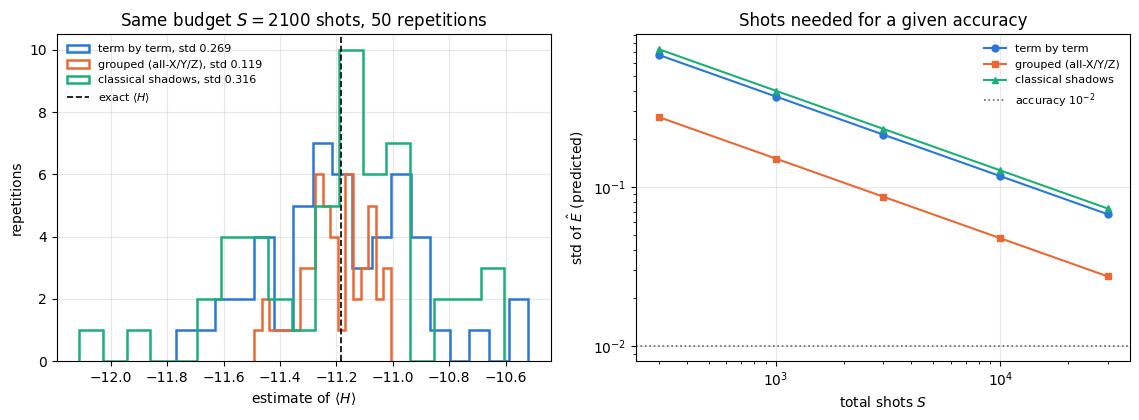


shots to reach a standard error of 0.01 on the energy (equal split / optimal split):
              term by term:    1.367e+06 /  9.005e+05
       grouped (all-X/Y/Z):    2.268e+05 /  2.027e+05
         classical shadows:    1.614e+06 /  1.614e+06

CHECKPOINT std over 50 repetitions vs prediction (relative SE of a sample std: 0.101):
    term by term: z = +0.65
         grouped: z = +1.57
         shadows: z = +1.49

CHECKPOINT S x Var from the per-shot variances (105000 shots per protocol)
      strategy           measured  Eqs. (5)-(8)       z  covariances dropped        z
  term by term    136.65 +-  0.42        136.70   -0.11
       grouped     22.69 +-  0.17         22.68   +0.02                19.53    +18.1
       shadows    160.28 +-  0.78        161.38   -1.42               108.51    +66.7


In [7]:
# ==============================================================================
# STEP 4: simulating the three protocols, many independent repetitions
# ==============================================================================
R_REP = 50                                     # independent repetitions of the whole protocol
M_GROUP = S_TOT // G_SETTINGS                  # shots per setting
M_TERM = S_TOT // T_TERMS                      # shots per term


def sample_shots(key, psi, n_shots, basis, chunk=20000):
    """`n_shots` measurements of every qubit in the SAME basis string, drawn in chunks.

    JAX  `jax.random.categorical` broadcasts the 2^N log-probabilities to (shots, 2^N); chunking keeps that
         intermediate bounded no matter how many shots the protocol asks for.
    """
    out, done = [], 0
    while done < n_shots:
        c = min(chunk, n_shots - done)
        out.append(sample_bitstrings(jax.random.fold_in(key, done), psi, c, bases=basis))
        done += c
    return jnp.concatenate(out)


@partial(jax.jit, static_argnums=(2,))
def shot_values(bits, digits, n_qubits):
    """+-1 value of every Pauli string for every shot of a setting that measured all of them.

    MATH  v_m(P) = prod_{q in supp(P)} (1 - 2 b_mq)    -- valid only when the setting satisfies Eq. (3).
    IMPL  for each qubit multiply by s_q where the string's digit is non-zero, by 1 where it is I.
    """
    s = (1 - 2 * bits).astype(RDTYPE)
    out = jnp.ones((bits.shape[0], digits.shape[0]), dtype=RDTYPE)
    for q in range(n_qubits):
        out = out * jnp.where(digits[:, q][None, :] == 0, 1.0, s[:, q][:, None])
    return out


# --- protocol 1: term by term ------------------------------------------------------------------
key = jax.random.PRNGKey(2024)
E_term = np.zeros(R_REP)
shots_term = {}                                                               # per-shot +-1 values, kept for 6.2
for p in "XYZ":
    idx = GROUPS[p]
    if not idx:
        continue
    bits = sample_shots(jax.random.fold_in(key, ord(p)), psi_vqe, R_REP * len(idx) * M_TERM, p * N_SITES)
    v = np.asarray(shot_values(bits, DIGITS[jnp.asarray(idx)], N_SITES))       # (R*n_g*m, n_g)
    v = v.reshape(R_REP, len(idx), M_TERM, len(idx))
    for j, t in enumerate(idx):                                               # term j uses only ITS OWN shots
        E_term += COEFFS[t] * v[:, j, :, j].mean(axis=1)
        shots_term[t] = v[:, j, :, j].reshape(-1)

# --- protocol 2: grouped settings --------------------------------------------------------------
E_group = np.zeros(R_REP)
shots_group = {}                                                              # per-shot partial energies A_g
for p in "XYZ":
    idx = GROUPS[p]
    if not idx:
        continue
    bits = sample_shots(jax.random.fold_in(key, 100 + ord(p)), psi_vqe, R_REP * M_GROUP, p * N_SITES)
    v = np.asarray(shot_values(bits, DIGITS[jnp.asarray(idx)], N_SITES)).reshape(R_REP, M_GROUP, len(idx))
    E_group += (v @ COEFFS[idx]).mean(axis=1)                                 # one partial energy per shot
    shots_group[p] = (v @ COEFFS[idx]).reshape(-1)

# --- protocol 3: classical shadows -------------------------------------------------------------
t0 = time.perf_counter()
bases_s, bits_s = collect_shadows(jax.random.PRNGKey(7), psi_vqe, R_REP * S_TOT)
vals_s = snapshot_values(bases_s, bits_s, DIGITS)
E_shadow = np.asarray((vals_s @ jnp.asarray(COEFFS)).reshape(R_REP, S_TOT).mean(axis=1))
print(f"collected {R_REP * S_TOT} snapshots in {time.perf_counter() - t0:.1f} s")

print(f"\n{R_REP} independent repetitions, total budget S = {S_TOT} shots each; exact <H> = {E_vqe:.5f}")
print(f"{'strategy':>24s} {'shots used':>11s} {'mean of estimates':>19s} {'measured std':>13s} "
      f"{'predicted std':>14s} {'ratio':>7s}")
for lab, est, v, used in (("term by term", E_term, var_term, T_TERMS * M_TERM),
                          ("grouped (all-X/Y/Z)", E_group, var_group, G_SETTINGS * M_GROUP),
                          ("classical shadows", E_shadow, var_shadow, S_TOT)):
    pred = np.sqrt(v / S_TOT)
    print(f"{lab:>24s} {used:11d} {est.mean():19.5f} {est.std():13.4f} {pred:14.4f} {est.std() / pred:7.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for j, (lab, est) in enumerate((("term by term", E_term), ("grouped (all-X/Y/Z)", E_group),
                                ("classical shadows", E_shadow))):
    axes[0].hist(est, bins=18, histtype="step", lw=1.8, color=PALETTE[j], label=f"{lab}, std {est.std():.3f}")
axes[0].axvline(E_vqe, color="k", ls="--", lw=1.2, label=r"exact $\langle H\rangle$")
axes[0].set_xlabel(r"estimate of $\langle H\rangle$"); axes[0].set_ylabel("repetitions")
axes[0].set_title(f"Same budget $S={S_TOT}$ shots, {R_REP} repetitions"); axes[0].legend(fontsize=8)

S_GRID = np.array([300, 1000, 3000, 10000, 30000])
for j, (lab, v) in enumerate((("term by term", var_term), ("grouped (all-X/Y/Z)", var_group),
                              ("classical shadows", var_shadow))):
    axes[1].loglog(S_GRID, np.sqrt(v / S_GRID), MARKERS[j] + "-", ms=5, color=PALETTE[j], label=lab)
axes[1].axhline(1e-2, color="0.4", ls=":", lw=1.2, label=r"accuracy $10^{-2}$")
axes[1].set_xlabel("total shots $S$"); axes[1].set_ylabel(r"std of $\hat E$ (predicted)")
axes[1].set_title("Shots needed for a given accuracy"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"\nshots to reach a standard error of 0.01 on the energy (equal split / optimal split):")
for lab, v, vo in (("term by term", var_term, PRED["term_opt"]), ("grouped (all-X/Y/Z)", var_group, PRED["group_opt"]),
                   ("classical shadows", var_shadow, var_shadow)):
    print(f"  {lab:>24s}: {v / 1e-4:12.3e} / {vo / 1e-4:10.3e}")

# --- CHECKPOINT 1: the spread over the 50 repetitions -------------------------------------------
# a standard deviation estimated from R Gaussian samples has relative standard error 1/sqrt(2(R-1))
se_rel = 1.0 / np.sqrt(2 * (R_REP - 1))
print(f"\nCHECKPOINT std over {R_REP} repetitions vs prediction (relative SE of a sample std: {se_rel:.3f}):")
for lab, est, v in (("term by term", E_term, var_term), ("grouped", E_group, var_group),
                    ("shadows", E_shadow, var_shadow)):
    z = (est.std(ddof=1) / np.sqrt(v / S_TOT) - 1) / se_rel
    print(f"  {lab:>14s}: z = {z:+.2f}")
    assert abs(z) < 4


# --- CHECKPOINT 2: the per-shot variances, pooled over all repetitions (a much sharper test) -----
def var_and_se(x):
    """Sample variance of x and its standard error sqrt((m4 - var^2)/n) from the sample 4th central moment."""
    x = np.asarray(x, dtype=float); d = x - x.mean(); v = np.mean(d ** 2)
    return v, np.sqrt((np.mean(d ** 4) - v ** 2) / len(x))


vt = {t: var_and_se(x) for t, x in shots_term.items()}
meas_term = T_TERMS * sum(COEFFS[t] ** 2 * vt[t][0] for t in vt)
se_term = T_TERMS * np.sqrt(sum((COEFFS[t] ** 2 * vt[t][1]) ** 2 for t in vt))
vg = {p: var_and_se(x) for p, x in shots_group.items()}
meas_group = G_SETTINGS * sum(v[0] for v in vg.values())
se_group = G_SETTINGS * np.sqrt(sum(v[1] ** 2 for v in vg.values()))
meas_shadow, se_shadow = var_and_se(np.asarray(vals_s @ jnp.asarray(COEFFS)))
ctrl_group = G_SETTINGS * PRED["diagonal"]            # WRONG control: covariances of Eq. (6) dropped
ctrl_shadow = PRED["shadow_diag"]                     # WRONG control: covariances of Eq. (7) dropped
print(f"\nCHECKPOINT S x Var from the per-shot variances ({R_REP * S_TOT} shots per protocol)")
print(f"{'strategy':>14s} {'measured':>18s} {'Eqs. (5)-(8)':>13s} {'z':>7s} {'covariances dropped':>20s} {'z':>8s}")
z_t = (meas_term - var_term) / se_term
z_g, zc_g = (meas_group - var_group) / se_group, (meas_group - ctrl_group) / se_group
z_s, zc_s = (meas_shadow - var_shadow) / se_shadow, (meas_shadow - ctrl_shadow) / se_shadow
print(f"{'term by term':>14s} {meas_term:9.2f} +- {se_term:5.2f} {var_term:13.2f} {z_t:+7.2f}")
print(f"{'grouped':>14s} {meas_group:9.2f} +- {se_group:5.2f} {var_group:13.2f} {z_g:+7.2f} "
      f"{ctrl_group:20.2f} {zc_g:+8.1f}")
print(f"{'shadows':>14s} {meas_shadow:9.2f} +- {se_shadow:5.2f} {var_shadow:13.2f} {z_s:+7.2f} "
      f"{ctrl_shadow:20.2f} {zc_s:+8.1f}")
assert max(abs(z_t), abs(z_g), abs(z_s)) < 4          # the derivation passes
assert min(abs(zc_g), abs(zc_s)) > 5                  # the covariance-free formulas fail

### 6.2 What the numbers say

**All three predictions pass both tests.** Over $50$ independent repetitions at $S=2100$ shots the measured standard
deviations are $0.269$, $0.119$ and $0.316$ against the predicted $0.255$, $0.104$ and $0.277$. A standard deviation
estimated from $50$ samples has a relative standard error of $1/\sqrt{2\cdot49}=0.10$, so these are $+0.7$, $+1.6$
and $+1.5$ standard errors: consistent, but with no power to tell the covariance-free grouped prediction
($\sqrt{19.53/2100}=0.096$) from the correct one. The sharp test is the per-shot variance pooled over all
$1.05\cdot10^{5}$ shots of each protocol: $S\,\mathrm{Var}=136.65\pm0.42$, $22.69\pm0.17$ and $160.28\pm0.78$ against
the predicted $136.70$, $22.68$ and $161.38$ ($-0.1$, $0.0$ and $-1.4$ standard errors), while the same formulas with
the covariances dropped, $19.53$ for grouping and $108.51$ for shadows, are rejected by $18$ and $67$ standard errors.
The estimators are unbiased within their errors: the means of the $50$ repetitions differ from
$\langle H\rangle=-11.185$ by $+0.2$, $-1.6$ and $-0.1$ standard errors of the mean.

**Grouping wins, by a factor of six against term-by-term and seven against shadows.** In variance at equal budget,
$136.7:22.7:161.4$. In machine runs needed for a standard error of $10^{-2}$ on the energy: $2.3\cdot10^{5}$ for the
grouped protocol against $1.4\cdot10^{6}$ and $1.6\cdot10^{6}$ for the other two. A fair comparison gives the
deterministic protocols their optimal shot allocation, Eqs. (5a) and (6a): term by term improves from $136.7$ to
$90.0$, grouping only from $22.7$ to $20.3$ (its three settings are already close to equally useful), and the
advantage of grouping over term by term shrinks from $6.0$ to $4.4$. For a **fixed, known** local Hamiltonian
grouping is the best of the three by a wide margin.

**Counting terms misses the covariances.** Naive counting predicts
$\mathrm{Var}_{\text{term}}/\mathrm{Var}_{\text{group}}=T/G=21/3=7$; the predicted ratio is $136.7/22.7=6.03$. The
difference is the covariance term of Eq. (6): the sum of the *individual* term variances is $6.51$, while the sum of
the grouped variances $\sum_g\mathrm{Var}(A_g)$ is $7.56$ — the covariances between terms measured in the same shot
are **positive** in aggregate here and inflate the grouped variance by $16\%$.

**Where the grouped variance lives is not where the terms are.** The per-setting contributions are $1.43$ (all-$X$,
eleven terms), $4.97$ (all-$Y$, five terms) and $1.16$ (all-$Z$, five terms). The $X$ setting carries twice as many
terms as the other two together and contributes least, because the state of Section 5 is nearly polarised along
$-x$: $\langle X_q\rangle\approx-0.98$ and $\langle X_qX_{q+1}\rangle\approx+0.98$, so each of those measurements is
nearly deterministic and the eleven individual variances add up to only $0.40$. The covariances, however, contribute
$+1.03$, more than twice that: the partial energy $A_X=-\sum_qX_qX_{q+1}+\sum_qX_q$ changes by $+6$ when a single
bulk spin is found flipped, because the field term and both bonds of that spin change sign *together*. The rare
flips are therefore counted three times over, coherently. In the $Y$ and $Z$ settings the covariances are small
($+0.09$ and $-0.06$) and the variance is that of the five correlators with $\lvert\langle YY\rangle\rvert$,
$\lvert\langle ZZ\rangle\rvert\approx0.15$. **The measurement cost of a Hamiltonian depends on the state being
measured**, and it changes during a VQE run.

**Shadows are the most expensive of the three here.** They pay the $3^k$ of Eq. (4) on every one of the $15$
weight-2 terms — the diagonal part of Eq. (7) alone is $108.5$ — and the positive covariances of Eq. (8) between
overlapping terms add another $52.9$, half as much again. The compensating property, one data set serving every
observable, is worth nothing when the observable list is a single known Hamiltonian. Section 7 changes the question.

## 7. One data set, many observables

The comparison of Section 6 was for a *fixed, known* Hamiltonian, which is the situation grouping is designed for.
The situation shadows are designed for is different: many observables, not all known in advance. Notebook 42 tracked
nine quantities; six of them are observables — the mean magnetisations $\langle X\rangle,\langle Y\rangle,\langle
Z\rangle$ and the mean bond correlators $\langle XX\rangle,\langle YY\rangle,\langle ZZ\rangle$ — built from
$3N+3(N-1)=33$ Pauli strings at $N=6$. We estimate all of them from the **same** shadow data set, and compare with
what the three grouped settings would give at the same total number of shots.

The comparison is predictable from the variance formulas, and it is worth writing down before measuring. For a
single weight-$k$ string $P$ at a total budget $S$:

* the grouped protocol measures $P$ in exactly one of its $G=3$ settings, which receives $S/3$ shots, and a shot
  there returns a $\pm1$ value, so $\mathrm{Var}_{\text{group}}=3\bigl(1-\langle P\rangle^2\bigr)/S$;
* shadows use all $S$ snapshots but pay the $3^k$ of Eq. (4), so
  $\mathrm{Var}_{\text{shadow}}=\bigl(3^k-\langle P\rangle^2\bigr)/S$.

The ratio is therefore

$$\frac{\mathrm{Var}_{\text{shadow}}}{\mathrm{Var}_{\text{group}}}
  =\frac{3^{k}-\langle P\rangle^{2}}{3\bigl(1-\langle P\rangle^{2}\bigr)}\;\ge\;1\quad(k\ge1) , \tag{9}$$

and it has two very different limits. For an observable with $\langle P\rangle\approx0$ it is $3^{k-1}$: shadows are
on par for single-site magnetisations and a factor of three in variance behind for bond correlators. But as
$\lvert\langle P\rangle\rvert\to1$ the denominator vanishes while the numerator does not, and the ratio **diverges**.
A dedicated setting measuring an almost deterministic observable gets it almost for free — every shot returns the
same sign — whereas a shadow data set still pays the full $3^k$ for the snapshots that happened to measure the wrong
axes. The state of Section 5 is nearly polarised, with $\langle X_q\rangle\approx-0.98$, so Eq. (9) predicts a
large ratio for the $X$-type strings and a modest one for the rest.

The six panel quantities are *averages* $\bar O=\frac1K\sum_jP_j$ over sites or bonds, and for an average the
covariances enter again. $\bar O$ is a "Hamiltonian" with $K$ terms of coefficient $1/K$, all read from one setting,
so Eqs. (6)-(8) apply unchanged. Two strings on disjoint sites have the same covariance
$\langle P_jP_l\rangle-\langle P_j\rangle\langle P_l\rangle$ in both protocols (Eq. (8) with $\lvert I\rvert=0$),
but in the grouped protocol it is multiplied by the same factor $3$ as the diagonal (one setting gets $S/3$ shots),
whereas for shadows the diagonal carries $3^k$ and the disjoint covariances only $1$. Positively correlated strings
therefore shift the balance towards shadows, negatively correlated ones towards grouping, and Eq. (9) need not hold
for an average. The measurement below computes both standard errors with all covariances and checks the shadow
one against the data.

20000 snapshots -> all 33 Pauli strings of the panel (2.2 s); none of them was chosen before the data were taken

observable     exact        shadow mean  bootstrap sd  median of means   deviation


       <X>   -0.9807      -0.9788 +- 0.0042        0.0041          -0.9815    +0.47 sd
       <Y>   +0.0003      -0.0077 +- 0.0053        0.0051          -0.0128    -1.51 sd


       <Z>   -0.0002      -0.0042 +- 0.0048        0.0052          +0.0005    -0.85 sd
      <XX>   +0.9828      +0.9785 +- 0.0106        0.0104          +0.9891    -0.40 sd


      <YY>   +0.1493      +0.1572 +- 0.0096        0.0100          +0.1677    +0.83 sd
      <ZZ>   -0.1439      -0.1489 +- 0.0094        0.0097          -0.1482    -0.52 sd

CHECKPOINT all 33 strings: largest deviation 3.01 standard errors, mean |deviation| 0.85 sd (expected for unbiased Gaussian errors: 0.80 +- 0.10)
WRONG CONTROL estimator without the factor 3^k: largest deviation 402 standard errors (blind to the strings with <P> = 0: smallest deviation 0.05)

standard error at S = 20000 shots: shadows vs the 3-setting protocol, covariances included
observable  k  shadow meas.  shadow Eq.(8)  shadow indep.  grouped Eq.(6)  grouped indep.  ratio  ratio indep.
       <X>  1       0.00416        0.00416        0.00412         0.00138         0.00098   3.01          4.22
       <Y>  1       0.00525        0.00524        0.00500         0.00569         0.00500   0.92          1.00


       <Z>  1       0.00476        0.00478        0.00500         0.00431         0.00500   1.11          1.00
      <XX>  2       0.01063        0.01056        0.00896         0.00132         0.00101   8.01          8.85
      <YY>  2       0.00962        0.00954        0.00947         0.00546         0.00541   1.75          1.75
      <ZZ>  2       0.00944        0.00943        0.00948         0.00528         0.00542   1.79          1.75


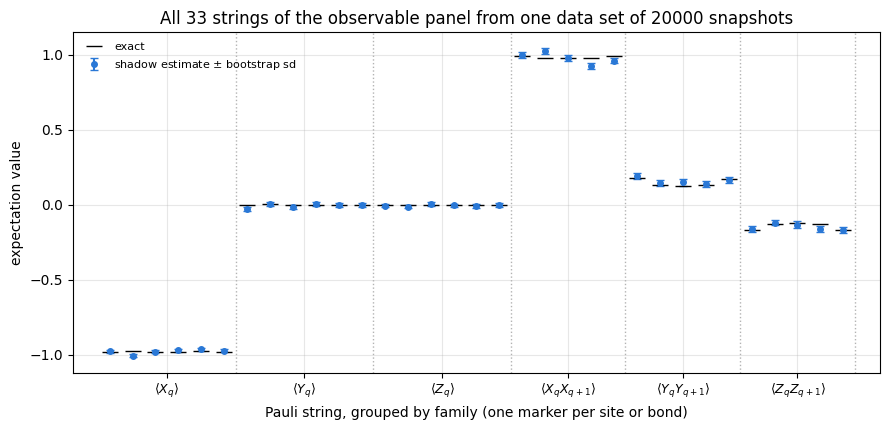

In [8]:
# ==============================================================================
# STEP 5: the whole observable panel of notebook 42, from one shadow data set
# ==============================================================================
M_PANEL, N_BOOT = 20000, 200
panel_labels, panel_kind = [], []
for p in "XYZ":
    for q in range(N_SITES):
        panel_labels.append("I" * q + p + "I" * (N_SITES - q - 1)); panel_kind.append(f"<{p}>")
for p in "XYZ":
    for q in range(N_SITES - 1):
        panel_labels.append("I" * q + p + p + "I" * (N_SITES - q - 2)); panel_kind.append(f"<{p}{p}>")
panel_dig = pauli_digits(panel_labels)
panel_exact = np.array([expect_label(psi_vqe, lab) for lab in panel_labels])

t0 = time.perf_counter()
bases_p, bits_p = collect_shadows(jax.random.PRNGKey(31), psi_vqe, M_PANEL)
vals_p = snapshot_values(bases_p, bits_p, panel_dig)
panel_mean = np.asarray(vals_p.mean(0))
panel_sem = np.asarray(vals_p.std(0) / np.sqrt(M_PANEL))
panel_boot = np.asarray(bootstrap_std(jax.random.PRNGKey(32), vals_p, N_BOOT))
panel_mom = np.asarray(median_of_means(vals_p, 9))
print(f"{M_PANEL} snapshots -> all {len(panel_labels)} Pauli strings of the panel "
      f"({time.perf_counter() - t0:.1f} s); none of them was chosen before the data were taken")

print(f"\n{'observable':>10s} {'exact':>9s} {'shadow mean':>18s} {'bootstrap sd':>13s} {'median of means':>16s} "
      f"{'deviation':>11s}")
groups_panel = {}
for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = [i for i, k in enumerate(panel_kind) if k == kind]
    groups_panel[kind] = sel
    ex = panel_exact[sel].mean()
    est = panel_mean[sel].mean()
    # the mean over sites of correlated estimators: build its per-snapshot value and bootstrap that
    per_snap = np.asarray(vals_p[:, jnp.asarray(sel)]).mean(axis=1)
    sem = per_snap.std() / np.sqrt(M_PANEL)
    boot = float(bootstrap_std(jax.random.PRNGKey(33), jnp.asarray(per_snap)[:, None], N_BOOT)[0])
    mom = float(median_of_means(jnp.asarray(per_snap)[:, None], 9)[0])
    print(f"{kind:>10s} {ex:+9.4f} {est:+12.4f} +- {sem:.4f} {boot:13.4f} {mom:+16.4f} "
          f"{(est - ex) / sem:+8.2f} sd")

dev = np.abs(panel_mean - panel_exact) / panel_sem
n_str = len(panel_labels)
print(f"\nCHECKPOINT all {n_str} strings: largest deviation {dev.max():.2f} standard errors, "
      f"mean |deviation| {dev.mean():.2f} sd (expected for unbiased Gaussian errors: "
      f"{np.sqrt(2 / np.pi):.2f} +- {np.sqrt((1 - 2 / np.pi) / n_str):.2f})")
assert dev.max() < 5.0
# WRONG control: the estimator without the factor 3 per qubit of Eq. (4), i.e. without the inverse channel
k_panel = np.array([sum(ch != "I" for ch in lab) for lab in panel_labels])
dev_ctrl = np.abs(panel_mean / 3.0 ** k_panel - panel_exact) / (panel_sem / 3.0 ** k_panel)
print(f"WRONG CONTROL estimator without the factor 3^k: largest deviation {dev_ctrl.max():.0f} standard errors "
      f"(blind to the strings with <P> = 0: smallest deviation {dev_ctrl.min():.2f})")
assert dev_ctrl.max() > 20

# --- what the grouped protocol would give at the same total budget ------------------------------
# The averaged observable (1/K) sum_j P_j is a 'Hamiltonian' with K terms of coefficient 1/K, all read from ONE
# setting, so Eqs. (6)-(8) apply unchanged: grouped per-shot variance = 3 x Var(A) (that setting gets S/3 shots),
# shadow per-snapshot variance = Eq. (7) with the covariances of Eq. (8).  'indep.' drops all covariances.
print(f"\nstandard error at S = {M_PANEL} shots: shadows vs the 3-setting protocol, covariances included")
print(f"{'observable':>10s} {'k':>2s} {'shadow meas.':>13s} {'shadow Eq.(8)':>14s} {'shadow indep.':>14s} "
      f"{'grouped Eq.(6)':>15s} {'grouped indep.':>15s} {'ratio':>6s} {'ratio indep.':>13s}")
panel_ratio = {}
for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = groups_panel[kind]
    k = 1 if len(kind) == 3 else 2
    ex = panel_exact[sel]
    K = len(sel)
    pk = predicted_variances(psi_vqe, [panel_labels[i] for i in sel], np.full(K, 1.0 / K), {kind[1]: list(range(K))})
    per_snap = np.asarray(vals_p[:, jnp.asarray(sel)]).mean(axis=1)
    sd_meas = per_snap.std() / np.sqrt(M_PANEL)
    sd_sh = np.sqrt(pk["shadow"] / M_PANEL)
    sd_sh_ind = np.sqrt(np.mean(3.0 ** k - ex ** 2) / K / M_PANEL)
    sd_gr = np.sqrt(3 * pk["parts"][kind[1]] / M_PANEL)
    sd_gr_ind = np.sqrt(3 * np.mean(1 - ex ** 2) / K / M_PANEL)
    panel_ratio[kind] = sd_sh / sd_gr
    print(f"{kind:>10s} {k:2d} {sd_meas:13.5f} {sd_sh:14.5f} {sd_sh_ind:14.5f} {sd_gr:15.5f} {sd_gr_ind:15.5f} "
          f"{sd_sh / sd_gr:6.2f} {sd_sh_ind / sd_gr_ind:13.2f}")
    assert abs(sd_meas / sd_sh - 1) < 0.05            # measured shadow error agrees with Eqs. (7)-(8)

fig, ax = plt.subplots(figsize=(9.0, 4.4))
xs = np.arange(len(panel_labels))
ax.errorbar(xs, panel_mean, yerr=panel_boot, fmt="o", ms=4, color=PALETTE[0], capsize=3,
            label=r"shadow estimate $\pm$ bootstrap sd")
ax.plot(xs, panel_exact, "k_", ms=12, label="exact")
KIND_TEX = {"<X>": r"$\langle X_q\rangle$", "<Y>": r"$\langle Y_q\rangle$", "<Z>": r"$\langle Z_q\rangle$",
            "<XX>": r"$\langle X_qX_{q+1}\rangle$", "<YY>": r"$\langle Y_qY_{q+1}\rangle$",
            "<ZZ>": r"$\langle Z_qZ_{q+1}\rangle$"}
centres, names_tex = [], []
for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = groups_panel[kind]
    centres.append(np.mean(sel)); names_tex.append(KIND_TEX[kind])
    ax.axvline(sel[-1] + 0.5, color="0.7", lw=1, ls=":")
ax.set_xticks(centres); ax.set_xticklabels(names_tex, fontsize=9)
ax.set_xlabel("Pauli string, grouped by family (one marker per site or bond)")
ax.set_ylabel("expectation value")
ax.set_title(f"All {len(panel_labels)} strings of the observable panel from one data set of {M_PANEL} snapshots")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Thirty-three Pauli strings, one data set, no prior decision.** The largest deviation from the exact value over the
$33$ strings is $3.0$ standard errors and the mean absolute deviation is $0.85$, against $\sqrt{2/\pi}=0.80\pm0.10$
expected for $33$ unbiased Gaussian errors. The same data processed without the factor $3^k$ of Eq. (4) miss by up to
$402$ standard errors; that control is blind only for the strings with $\langle P\rangle\approx0$, where both
estimators have mean zero. The bootstrap standard deviations agree with the analytic $\sigma/\sqrt M$ within the
$\pm5\%$ Monte-Carlo resolution of $200$ resamples, as they must for a plain sample mean.

**The measured shadow errors agree with Eqs. (7)-(8) to better than $2\%$ for all six quantities, and the ratio to
the grouped protocol behaves as derived.** The last two columns of the second table are the ratio of the shadow
standard error to the grouped one, with and without the covariances:

* $\langle YY\rangle$ and $\langle ZZ\rangle$, weight $2$ with $\langle P\rangle\approx\pm0.15$: ratios $1.75$ and
  $1.79$, close to the $\sqrt{3^{k-1}}=\sqrt3=1.73$ of Eq. (9); the covariances nearly cancel here;
* $\langle X\rangle$ and $\langle XX\rangle$, whose strings have expectation values $-0.98$ and $+0.98$: ratios $3.0$
  and $8.0$. This is the divergent limit of Eq. (9). A dedicated $X$ setting measuring an almost deterministic
  observable gets it cheaply — each string has variance $1-\langle P\rangle^2\approx0.04$ — while the shadow
  estimator still pays $3^k$ for the snapshots that measured the wrong axes. The covariances matter for both: they
  double the grouped variance of $\langle X\rangle$ (the correlated flips of Section 6.2) and the formula without
  them overstates the ratio, $4.2$ and $8.9$;
* $\langle Y\rangle$ and $\langle Z\rangle$, weight $1$ with $\langle P\rangle\approx0$, where Eq. (9) gives
  $1$ for every single string: the averages come out at $0.92$ and $1.11$. The $Y_q$ of this state are positively
  correlated, which raises the grouped variance of the average by $30\%$ and the shadow variance by only $10\%$, so
  for $\langle Y\rangle$ **shadows beat the grouped protocol**; the $Z_q$ are anticorrelated and the balance tips the
  other way.

For a single Pauli string shadows are never cheaper than a setting that contains it, by Eq. (9); for sums of
strings the covariances can reverse that by a modest margin. The range here is from $0.9$ to $8$ in standard error.
What shadows buy is elsewhere: the data set was collected before any of these $33$ strings was named, and
estimating a thirty-fourth — say $\langle X_0Y_2Z_4\rangle$ — costs nothing extra, whereas the grouped protocol
would need a new setting and a new experiment. The trade is **variance for adaptivity**, and the rigorous version of
that statement is the $\log K$ scaling of notebook 24, Eq. (8).

> **Numerical practice.** Formulas that treat the $N$ site estimators (or $N-1$ bond estimators) of an average as
> independent are wrong in both directions here: they put the shadow error of $\langle XX\rangle$ at $0.0090$
> instead of the measured $0.0106$ (neighbouring bonds share a qubit, so Eq. (8) correlates them positively), and
> the grouped error of $\langle X\rangle$ at $0.00098$ instead of $0.00138$. Compute variances of averages from the
> per-snapshot (or per-shot) values of the average itself, or from the full covariance formulas.

## 8. Shadow-estimated energies inside the optimisation loop

So far the state was fixed. Now the shadows drive the optimisation: at every iteration the cost is estimated from a
fresh data set of $M$ snapshots, and the optimiser never sees anything else. The gradient rule must therefore be one
that tolerates a noisy cost, which is SPSA (notebook 41): two cost evaluations per iteration, hence $2M$ snapshots
per iteration, whatever the number of angles.

Two changes with respect to the previous sections. First, the chain is shortened to $N=4$ with $L=2$ layers
($n=24$ angles): SPSA needs hundreds of iterations to converge and each iteration buys $2M$ snapshots, so a
meaningful budget scan is only affordable on a small system. Everything else — the Hamiltonian, the couplings, the
estimator — is unchanged. Second, the step size is measured rather than assumed: first on the *exact* cost, because a
step size tuned for reverse-mode gradients has no reason to suit SPSA, and then again around that value with the
shadow costs, because the best step of a noisy optimisation can differ from the noise-free one. Every comparison
below is between runs at their own best step.

> **JAX practice.** The shadow cost has to live *inside* a `lax.scan` body that is itself `vmap`ped over restarts,
> so every snapshot of every restart of every iteration is generated in one compiled program. The memory that costs
> is (runs) $\times$ $M$ $\times$ $2^N$ complex numbers of $16$ bytes for the batched rotated states; with
> $3\times6$ runs (three step sizes, six restarts), $M=1024$ and $N=4$ that is $4.7\cdot10^{6}$ bytes. It is the
> quantity to check before raising $N$ or $M$: at $N=6$ and $M=2048$ the same expression is already
> $3.8\cdot10^{7}$ bytes per evaluation.

The diagnostic plotted is the **exact** energy error of the current angles, which the optimiser never sees. Plotting
the noisy estimate instead would be the mistake analysed in Section 9.

In [9]:
# ==============================================================================
# STEP 6: a shadow-based cost function, jit-able and vmap-able
# ==============================================================================
ROTS = jnp.stack([_BASIS_ROT["X"], _BASIS_ROT["Y"], _BASIS_ROT["Z"]])


def shadow_snapshots(key, psi, n_snap):
    """`n_snap` random-Pauli snapshots of `psi`, generated inside a traced function.

    MATH   one snapshot = draw a basis code per qubit, rotate, sample ONE bit string from the Born rule
    IMPL   this is the engine's `collect_pauli_shadows` written out, so that it can be inlined in a training
           loop without the Python-level chunking of `collect_shadows` (which cannot be traced).
    COST   O(M N 2^N) time, O(M 2^N) memory.
    """
    N = psi.ndim

    def one(k):
        kb, ks = jax.random.split(k)
        bases = jax.random.randint(kb, (N,), 0, 3)
        phi = psi
        for q in range(N):
            phi = apply_gate(phi, ROTS[bases[q]], [q])
        logp = jnp.log(jnp.clip(jnp.abs(phi.reshape(-1)) ** 2, 1e-300, None))
        idx = jax.random.categorical(ks, logp)
        return bases, (idx >> jnp.arange(N - 1, -1, -1)) & 1

    return jax.vmap(one)(jax.random.split(key, n_snap))


def shadow_energy(key, psi, n_snap, digits, coeffs):
    """Energy estimate of `psi` from `n_snap` fresh snapshots: E_hat = (1/M) sum_m sum_t c_t o_m(P_t)."""
    bases, bits = shadow_snapshots(key, psi, n_snap)
    return jnp.mean(snapshot_values(bases, bits, digits) @ coeffs)


# --- the smaller chain used for the in-loop study ------------------------------------------------
N_LOOP, L_LOOP = 4, 2
n_loop = hea_num_params(N_LOOP, L_LOOP)
terms_loop = model_terms(N_LOOP, c_model)
E0_loop, psi0_loop = lanczos_ground_state(terms_loop, N_LOOP)
psi0_loop = psi0_loop / jnp.linalg.norm(psi0_loop)
LABELS_L, COEFFS_L = hamiltonian_pauli_list(N_LOOP, MODELS[MODEL])
DIG_L, COEF_L = pauli_digits(LABELS_L), jnp.asarray(COEFFS_L)
GROUPS_L = {p: [t for t, lab in enumerate(LABELS_L) if set(lab) - {"I"} == {p}] for p in "XYZ"}
cost_loop = jax.jit(lambda t: energy(terms_loop, hardware_efficient_ansatz(t, N_LOOP, L_LOOP)))
err_loop = jax.jit(lambda t: cost_loop(t) - E0_loop)
print(f"in-loop system: {MODEL} chain, N={N_LOOP}, L={L_LOOP}, n={n_loop} angles, "
      f"T={len(LABELS_L)} Pauli terms; exact E_0 = {E0_loop:.6f}")

# --- CHECKPOINT: the in-loop estimator itself is unbiased and its spread follows Eqs. (7) and (8) --
# The test uses `shadow_snapshots`, the traced sampler that runs inside the training loop (not the engine
# collector of the previous sections), in chunks of 4096 snapshots with keys fold_in(key, j).
M_CHK, CHK_CHUNK = 61440, 4096
_snap_vals = jax.jit(lambda k, psi: snapshot_values(*shadow_snapshots(k, psi, CHK_CHUNK), DIG_L) @ COEF_L)
e_per_snap = np.concatenate([np.asarray(_snap_vals(jax.random.fold_in(jax.random.PRNGKey(55), j), psi0_loop))
                             for j in range(M_CHK // CHK_CHUNK)])
PRED_L = predicted_variances(psi0_loop, LABELS_L, COEFFS_L, GROUPS_L)
print(f"\nexact E of the state measured: {E0_loop:.6f};   one data set of {M_CHK} snapshots cut into blocks")
print(f"{'block size M':>13s} {'blocks':>7s} {'mean of block means':>21s} {'std of block means':>20s} "
      f"{'predicted std':>14s} {'z':>6s}")
for M in (128, 512, 2048):
    nb_ = M_CHK // M
    blocks = e_per_snap[: nb_ * M].reshape(nb_, M).mean(axis=1)
    sd_pred = np.sqrt(PRED_L['shadow'] / M)
    # relative standard error of a sample std from nb_ (nearly Gaussian) block means: 1/sqrt(2(nb_-1))
    z = (blocks.std(ddof=1) / sd_pred - 1) * np.sqrt(2 * (nb_ - 1))
    print(f"{M:13d} {nb_:7d} {blocks.mean():21.5f} {blocks.std(ddof=1):20.5f} {sd_pred:14.5f} {z:+6.2f}")
v_chk, se_chk = var_and_se(e_per_snap)
z_mean = (e_per_snap.mean() - E0_loop) / (e_per_snap.std() / np.sqrt(M_CHK))
z_var = (v_chk - PRED_L["shadow"]) / se_chk
z_var_ctrl = (v_chk - PRED_L["shadow_diag"]) / se_chk
print(f"CHECKPOINT mean: {e_per_snap.mean():.5f} vs E_0 = {E0_loop:.5f}, z = {z_mean:+.2f}")
print(f"CHECKPOINT single-snapshot variance: measured {v_chk:.2f} +- {se_chk:.2f}, Eqs. (7)-(8) "
      f"{PRED_L['shadow']:.2f} (z = {z_var:+.2f});  WRONG CONTROL without covariances {PRED_L['shadow_diag']:.2f} "
      f"(z = {z_var_ctrl:+.1f})")
assert abs(z_mean) < 4 and abs(z_var) < 4 and abs(z_var_ctrl) > 5

in-loop system: XXZ chain, N=4, L=2, n=24 angles, T=13 Pauli terms; exact E_0 = -7.124149



exact E of the state measured: -7.124149;   one data set of 61440 snapshots cut into blocks
 block size M  blocks   mean of block means   std of block means  predicted std      z
          128     480              -7.18457              0.87911        0.86625  +0.46
          512     120              -7.18457              0.42661        0.43312  -0.23
         2048      30              -7.18457              0.21967        0.21656  +0.11
CHECKPOINT mean: -7.18457 vs E_0 = -7.12415, z = -1.52
CHECKPOINT single-snapshot variance: measured 96.63 +- 0.63, Eqs. (7)-(8) 96.05 (z = +0.93);  WRONG CONTROL without covariances 65.93 (z = +49.0)


In [10]:
# ==============================================================================
# STEP 7: the SPSA step size, measured on the exact cost
# ==============================================================================
def grad_spsa_exact(cost, c=0.2, gamma=0.101):
    """SPSA gradient rule with Spall's probe radius c_k = c/k^gamma and an exact cost (notebook 41)."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
        return (cost(theta + c_k * delta) - cost(theta - c_k * delta)) / (2 * c_k) * delta
    return rule


def grad_spsa_shadow(n_snap, c=0.2, gamma=0.101):
    """The same rule with both cost evaluations replaced by shadow estimates from `n_snap` snapshots."""
    def rule(theta, key, k):
        c_k = c / k ** gamma
        kd, kp, km = jax.random.split(key, 3)
        delta = jax.random.rademacher(kd, theta.shape).astype(theta.dtype)
        cp = shadow_energy(kp, hardware_efficient_ansatz(theta + c_k * delta, N_LOOP, L_LOOP),
                           n_snap, DIG_L, COEF_L)
        cm = shadow_energy(km, hardware_efficient_ansatz(theta - c_k * delta, N_LOOP, L_LOOP),
                           n_snap, DIG_L, COEF_L)
        return (cp - cm) / (2 * c_k) * delta
    return rule


R_LOOP, T_LOOP = 6, 500
th_l, ks_l = random_starts(R_LOOP, n_loop, seed=301)
LR_GRID_SPSA = jnp.asarray([0.01, 0.02, 0.05, 0.1, 0.2, 0.4], dtype=RDTYPE)
t0 = time.perf_counter()
H_lr = np.asarray(jax.block_until_ready(jax.jit(jax.vmap(lambda lr: jax.vmap(lambda t, k: train(
    t, k, grad_spsa_exact(cost_loop), opt_adam(lr), err_loop, T_LOOP)[1])(th_l, ks_l)))(LR_GRID_SPSA)))
print(f"SPSA step-size sweep on the EXACT cost ({len(LR_GRID_SPSA)} rates x {R_LOOP} restarts x {T_LOOP} "
      f"iterations, one compilation) in {time.perf_counter() - t0:.1f} s")
print(f"{'step size':>10s} {'median final E-E_0':>20s}")
med_lr = np.median(H_lr[:, :, -1], axis=1)
for j, lr in enumerate(np.asarray(LR_GRID_SPSA)):
    print(f"{lr:10.3g} {med_lr[j]:20.5f}")
LR_LOOP = float(np.asarray(LR_GRID_SPSA)[int(np.argmin(med_lr))])
h_spsa_exact = H_lr[int(np.argmin(med_lr))]
print(f"best SPSA step size: {LR_LOOP:g}")
assert 0 < int(np.argmin(med_lr)) < len(LR_GRID_SPSA) - 1     # the optimum is bracketed by the grid

SPSA step-size sweep on the EXACT cost (6 rates x 6 restarts x 500 iterations, one compilation) in 2.0 s
 step size   median final E-E_0
      0.01              0.13331
      0.02              0.05225
      0.05              0.12575
       0.1              0.69198
       0.2              1.61494
       0.4              4.31968
best SPSA step size: 0.02


3 shadow budgets x 3 step sizes x 6 restarts x 500 iterations in 28.9 s: compilation 2.8, 2.3, 2.3 s, execution 1.9, 4.7, 14.8 s for M = (64, 256, 1024); exact-gradient references in 3.3 s

step-size check with shadow costs (median final E-E_0 over 6 restarts):
     M    eta=0.01    eta=0.02    eta=0.05     best
    64      2.1786      1.0067      1.7620     0.02
   256      0.6460      0.3369      1.0171     0.02
  1024      0.3219      0.1721      0.6123     0.02

 snapshots/iteration  total snapshots  cost noise std at E_0     median final E-E_0      best
                 128            64000                 1.2251       1.0067 +- 0.3443   0.35896
                 512           256000                 0.6125       0.3369 +- 0.0286   0.27158
                2048          1024000                 0.3063       0.1721 +- 0.0123   0.14645
    exact cost, SPSA                0                 0.0000       0.0523 +- 0.0120   0.03444
exact gradient, Adam                0                 0.000


log-log slope of the median final error against M: -0.64 +- 0.12 (bootstrap)


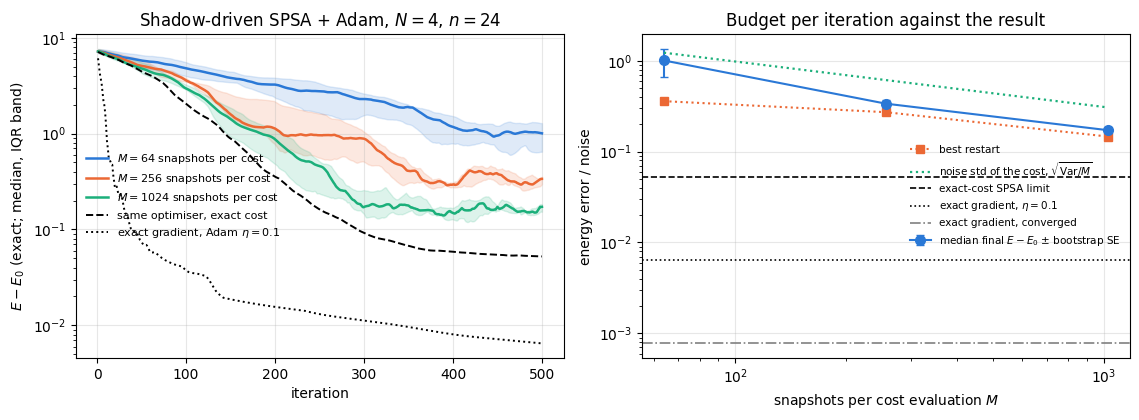

In [11]:
# ==============================================================================
# STEP 8: training with shadow-estimated costs, at three snapshot budgets
# ==============================================================================
SNAP_BUDGETS = (64, 256, 1024)
LR_SHADOW = jnp.asarray([0.5 * LR_LOOP, LR_LOOP, 2.5 * LR_LOOP], dtype=RDTYPE)   # re-tune around the exact-cost optimum
_rng_med = np.random.default_rng(0)


def median_se(x, n_boot=2000):
    """Bootstrap standard error of the median of a small sample (resampling the restarts)."""
    x = np.asarray(x)
    return float(np.std(np.median(_rng_med.choice(x, (n_boot, len(x))), axis=1)))


loop_hist, loop_theta, lr_best, med_scan, t_comp, t_run = {}, {}, {}, {}, {}, {}
t0 = time.perf_counter()
for M in SNAP_BUDGETS:
    # one compilation per budget: vmap over the three step sizes and the restarts.  Ahead-of-time
    # lower().compile() separates the compilation time from the execution time.
    fn = jax.jit(jax.vmap(lambda lr: jax.vmap(lambda t, k: train(
        t, k, grad_spsa_shadow(M), opt_adam(lr), err_loop, T_LOOP))(th_l, ks_l)))
    tc = time.perf_counter(); compiled = fn.lower(LR_SHADOW).compile(); t_comp[M] = time.perf_counter() - tc
    tc = time.perf_counter(); th_f, h = jax.block_until_ready(compiled(LR_SHADOW)); t_run[M] = time.perf_counter() - tc
    h = np.asarray(h)
    med_scan[M] = np.median(h[:, :, -1], axis=1)
    j = int(np.argmin(med_scan[M]))
    lr_best[M], loop_hist[M], loop_theta[M] = float(LR_SHADOW[j]), h[j], th_f[j]
t_shadow = time.perf_counter() - t0
th_grad, h_grad = jax.block_until_ready(jax.jit(jax.vmap(lambda t, k: train(
    t, k, grad_exact(cost_loop), opt_adam(0.1), err_loop, T_LOOP)))(th_l, ks_l))
h_grad = np.asarray(h_grad)
# the exact-gradient runs at a constant Adam step sit on a step-size floor (notebook 42, Section 8.1);
# continuing them with a ten times smaller step gives an upper bound on the true ansatz floor
_, h_floor = jax.block_until_ready(jax.jit(jax.vmap(lambda t, k: train(
    t, k, grad_exact(cost_loop), opt_adam(0.01), err_loop, 3000)))(th_grad, ks_l))
h_floor = np.asarray(h_floor)
print(f"{len(SNAP_BUDGETS)} shadow budgets x {len(LR_SHADOW)} step sizes x {R_LOOP} restarts x {T_LOOP} iterations "
      f"in {t_shadow:.1f} s: compilation " + ", ".join(f"{t_comp[M]:.1f}" for M in SNAP_BUDGETS)
      + " s, execution " + ", ".join(f"{t_run[M]:.1f}" for M in SNAP_BUDGETS) + f" s for M = {SNAP_BUDGETS}; "
      f"exact-gradient references in "
      f"{time.perf_counter() - t0 - t_shadow:.1f} s")

print(f"\nstep-size check with shadow costs (median final E-E_0 over {R_LOOP} restarts):")
print(f"{'M':>6s} " + " ".join(f"{'eta=' + format(float(lr), 'g'):>11s}" for lr in LR_SHADOW) + f" {'best':>8s}")
for M in SNAP_BUDGETS:
    print(f"{M:6d} " + " ".join(f"{m:11.4f}" for m in med_scan[M]) + f" {lr_best[M]:8g}")

print(f"\n{'snapshots/iteration':>20s} {'total snapshots':>16s} {'cost noise std at E_0':>22s} "
      f"{'median final E-E_0':>22s} {'best':>9s}")
for M in SNAP_BUDGETS:
    h = loop_hist[M]
    print(f"{2 * M:20d} {2 * M * T_LOOP:16d} {np.sqrt(PRED_L['shadow'] / M):22.4f} "
          f"{np.median(h[:, -1]):12.4f} +- {median_se(h[:, -1]):6.4f} {h[:, -1].min():9.5f}")
print(f"{'exact cost, SPSA':>20s} {0:16d} {0.0:22.4f} {np.median(h_spsa_exact[:, -1]):12.4f} +- "
      f"{median_se(h_spsa_exact[:, -1]):6.4f} {h_spsa_exact[:, -1].min():9.5f}")
print(f"{'exact gradient, Adam':>20s} {0:16d} {0.0:22.4f} {np.median(h_grad[:, -1]):12.5f} +- "
      f"{median_se(h_grad[:, -1]):6.5f} {h_grad[:, -1].min():9.5f}    (eta = 0.1, same {T_LOOP} iterations)")
print(f"{'+3000 its at eta=0.01':>20s} {0:16d} {0.0:22.4f} {np.median(h_floor[:, -1]):12.5f} +- "
      f"{median_se(h_floor[:, -1]):6.5f} {h_floor[:, -1].min():9.5f}    (upper bound on the ansatz floor)")
slope = np.polyfit(np.log(SNAP_BUDGETS), np.log([np.median(loop_hist[M][:, -1]) for M in SNAP_BUDGETS]), 1)[0]
boot_slopes = [np.polyfit(np.log(SNAP_BUDGETS), np.log([np.median(_rng_med.choice(loop_hist[M][:, -1], R_LOOP))
                                                        for M in SNAP_BUDGETS]), 1)[0] for _ in range(2000)]
print(f"\nlog-log slope of the median final error against M: {slope:.2f} +- {np.std(boot_slopes):.2f} (bootstrap)")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
it = np.arange(1, T_LOOP + 1)
for j, M in enumerate(SNAP_BUDGETS):
    lo, med, hi = bands(np.maximum(loop_hist[M], 1e-6))
    axes[0].fill_between(it, lo, hi, color=PALETTE[j], alpha=0.15)
    axes[0].semilogy(it, med, "-", lw=1.8, color=PALETTE[j], label=f"$M={M}$ snapshots per cost")
_, med_ref, _ = bands(np.maximum(h_spsa_exact, 1e-6))
axes[0].semilogy(it, med_ref, "k--", lw=1.4, label="same optimiser, exact cost")
_, med_g, _ = bands(np.maximum(h_grad, 1e-6))
axes[0].semilogy(it, med_g, "k:", lw=1.4, label=r"exact gradient, Adam $\eta=0.1$")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$E-E_0$ (exact; median, IQR band)")
axes[0].set_title(f"Shadow-driven SPSA + Adam, $N={N_LOOP}$, $n={n_loop}$"); axes[0].legend(fontsize=8)

meds = [np.median(loop_hist[M][:, -1]) for M in SNAP_BUDGETS]
axes[1].errorbar(SNAP_BUDGETS, meds, yerr=[median_se(loop_hist[M][:, -1]) for M in SNAP_BUDGETS],
                 fmt=MARKERS[0] + "-", ms=7, capsize=3, color=PALETTE[0], label=r"median final $E-E_0$ $\pm$ bootstrap SE")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].loglog(SNAP_BUDGETS, [loop_hist[M][:, -1].min() for M in SNAP_BUDGETS], MARKERS[1] + ":", ms=6,
               color=PALETTE[1], label="best restart")
axes[1].loglog(SNAP_BUDGETS, [np.sqrt(PRED_L["shadow"] / M) for M in SNAP_BUDGETS], ":", color=PALETTE[2],
               lw=1.6, label=r"noise std of the cost, $\sqrt{\mathrm{Var}/M}$")
axes[1].axhline(np.median(h_spsa_exact[:, -1]), color="k", ls="--", lw=1.2, label="exact-cost SPSA limit")
axes[1].axhline(np.median(h_grad[:, -1]), color="k", ls=":", lw=1.2, label=r"exact gradient, $\eta=0.1$")
axes[1].axhline(np.median(h_floor[:, -1]), color="0.5", ls="-.", lw=1.2, label="exact gradient, converged")
axes[1].set_xlabel("snapshots per cost evaluation $M$"); axes[1].set_ylabel("energy error / noise")
axes[1].set_title("Budget per iteration against the result"); axes[1].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

**The in-loop estimator passes the same tests as the engine collector.** The checkpoint draws its snapshots with
`shadow_snapshots`, the traced sampler used inside the training loop. Its mean misses $E_0$ by $1.5$ standard errors,
and its single-snapshot variance is $96.63\pm0.63$ against $96.05$ from Eqs. (7)-(8) ($+0.9$ standard errors), while
the formula without the covariances, $65.93$, is rejected by $49$ standard errors. The spreads of the block means
agree with $\sqrt{\mathrm{Var}/M}$ within half a standard error at all three block sizes (the three rows reuse the
same snapshots, so they are not independent tests).

**The step size dominates everything, again.** On the exact cost the median final error is $0.052$ at the best step
$\eta=0.02$, $0.13$ at both neighbours $0.01$ and $0.05$, and $4.32$ at $\eta=0.4$ — a factor of $80$ from one
hyper-parameter, measured without shadows so that the shadows are not blamed for it. The step $0.4$ that served Adam
with exact gradients in notebook 42 is the worst one here. With shadow costs the same step $\eta=0.02$ is again the
best at every budget; halving it or multiplying it by $2.5$ makes the median worse by a factor of $1.7$ to $3.6$. The
budget comparison below is therefore between tuned runs.

**The snapshot budget per iteration sets the answer, through the cost noise.** The median final energy error is
$1.01\pm0.34$ at $M=64$, $0.337\pm0.029$ at $M=256$ and $0.172\pm0.012$ at $M=1024$ (bootstrap errors over the six
restarts), while the standard deviation of the cost estimate near the ground state is $1.23$, $0.61$ and $0.31$. From
$M=256$ to $M=1024$ the median halves, as an $M^{-1/2}$ law would have it, and the fitted slope over the three
budgets is $-0.64\pm0.12$; six restarts and three budgets do not determine the exponent better than that. Accuracy
improving only as $M^{-1/2}$ (or not much faster) means that each extra digit costs about a hundred times the
measurements.

**Two references sit underneath, and only one of them is the ansatz.** The same optimiser with an exact cost
reaches $0.052$; the same circuit with exact gradients and Adam at $\eta=0.1$ reaches $0.0065$ in the same $500$
iterations. That second number is Adam's constant-step floor (notebook 42, Section 8.1) rather than a property of
the circuit: continuing those runs for $3000$ iterations at $\eta=0.01$ brings the median to $7.8\cdot10^{-4}$. So of the
$0.17$ reached with $10^{6}$ snapshots per run, a factor of three is the shadow noise, a factor of eight is SPSA
against exact gradients at an equal number of iterations, a further factor of eight is the constant step of the
exact-gradient reference, and at most $8\cdot10^{-4}$ is the ansatz. **Reporting the ansatz error of a shadow-driven
VQE run without these references would attribute to the circuit what belongs to the measurement budget and to the
optimiser.**

## 9. Optimisation bias: the winner's curse

A noisy cost biases a variational calculation in two opposite directions. The **true** energy of the parameters an
optimiser returns can only be too high: $E(\boldsymbol\theta)\ge E_0$ for every $\boldsymbol\theta$, so noise that
keeps the optimiser away from the minimum adds a positive error — that is what Section 8 measured. The **reported**
energy, the noisy value an experimenter reads off at the end, is biased the other way.

Let $\hat C_i=C_i+\varepsilon_i$ be independent noisy estimates of the true costs $C_i$ of $R$ candidates
(restarts, iterations, hyper-parameter settings), with $\mathbb E[\varepsilon_i]=0$. Selecting the candidate with
the smallest $\hat C$ and reporting its $\hat C$ is biased low in two senses. First, $\min_i\hat C_i\le\hat C_j$ for
every $j$, so taking expectations,

$$\mathbb E\Bigl[\min_i\hat C_i\Bigr]\;\le\;\min_j\mathbb E\bigl[\hat C_j\bigr]=\min_jC_j . \tag{10}$$

Second, the reported value minus the true cost of the *selected* candidate, $\varepsilon_{i^*}$, has negative mean:
candidate $i$ is selected exactly when $\varepsilon_i$ falls below a threshold $t_i$ set by the other candidates, and
for a zero-mean variable $\mathbb E[\varepsilon\,\mathbb 1\{\varepsilon<t\}]\le0$ for every $t$ (for $t\le0$ the
integrand is negative; for $t>0$ it equals $-\mathbb E[\varepsilon\,\mathbb 1\{\varepsilon\ge t\}]\le0$). Summing
over $i$ gives $\mathbb E[\varepsilon_{i^*}]\le0$.

The size follows from two limits. If the true costs differ by much more than the noise, the selection always picks
the same candidate and the bias vanishes. If they are equal and the noise is Gaussian with standard deviation
$\sigma$, then $\varepsilon_{i^*}=\min_i\varepsilon_i$ and

$$\mathbb E\bigl[\varepsilon_{i^*}\bigr]=-\sigma\,e_R ,\qquad
  e_R=\mathbb E\Bigl[\max_{i\le R}z_i\Bigr]=\int_{-\infty}^{\infty}x\,R\,\varphi(x)\,\Phi(x)^{R-1}\,dx , \tag{11}$$

with $z_i$ independent standard normals, $\varphi$ and $\Phi$ their density and distribution function. For $R=2$,
$e_2=1/\sqrt\pi=0.56$; for the $R=6$ restarts of Section 8, $e_6=1.27$; for large $R$, $e_R\approx\sqrt{2\ln R}$, which
overestimates it at small $R$ ($1.89$ for $R=6$). Between the two limits the bias depends on the spacing of the
$C_i$ relative to $\sigma$, and a Gaussian model with the actual $C_i$ and $\sigma_i$ predicts it. The selected
candidate is also not necessarily the best one: it is the one whose noise happened to be most favourable, so its
true cost $C_{i^*}\ge\min_iC_i$ is biased *up*. In statistics this is the *winner's curse*; in a variational
calculation it is how a quoted energy can sit below the true ground energy and appear to violate the variational
principle.

The remedy: **re-estimate the final answer with an independent data set**, large enough that its own error bar is
small, and quote that. The experiment below repeats the selection among the six final states of Section 8 a hundred
times with fresh data, compares the mean bias with the Gaussian model built from the exact $C_i$ and the
$\sigma_i$ of Eqs. (7)-(8), and then re-measures the selected states independently.

e_R for R = 6 candidates: 1.2672   (asymptotic form sqrt(2 ln R) = 1.8930)


1818 data sets collected in 7.7 s

     M  sigma/sqrt(M)  spread of C_r   mean bias (measured)  Gaussian model  equal-cost limit      z  z (no bias)  P(pick best)        no selection
    64         1.2171         0.7324       -1.3332 +- 0.0915         -1.3752           -1.5424  +0.46        -14.6   0.33 (0.32)   -0.0023 +- 0.0495
   256         0.6144         0.0572       -0.7736 +- 0.0409         -0.7757           -0.7786  +0.05        -18.9   0.21 (0.19)   +0.0203 +- 0.0252
  1024         0.3075         0.0210       -0.3840 +- 0.0213         -0.3878           -0.3897  +0.18        -18.0   0.18 (0.19)   +0.0097 +- 0.0126

one experiment (repetition 0) and the independent re-measurement with 30000 snapshots:
     M  picked   reported  re-measured     exact  re-measurement cost
    64       2    -8.2266      -6.2796   -6.2821                 47%
   256       0    -7.5293      -6.8140   -6.8368                 12%
  1024       4    -7.5718      -6.9215   -6.9182                  3%
CHECK

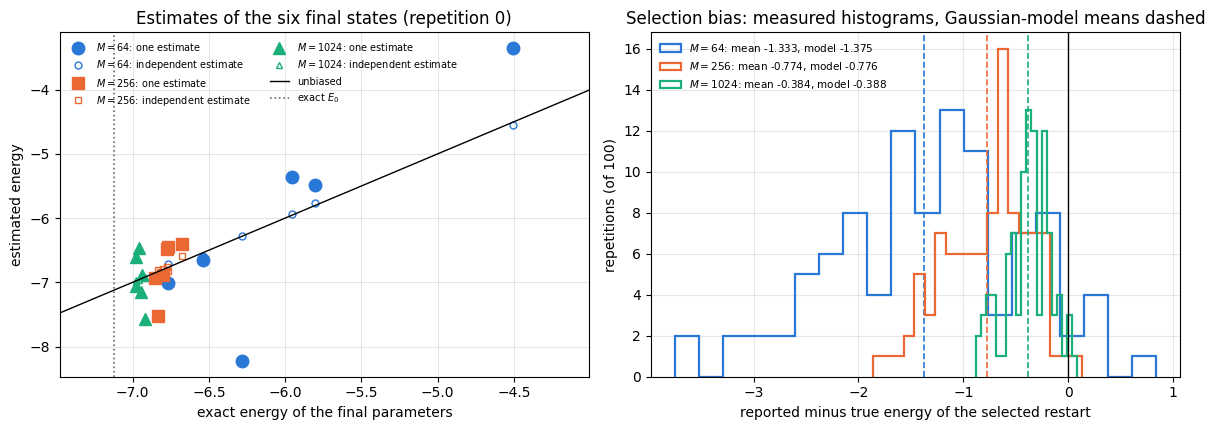

In [12]:
# ==============================================================================
# STEP 9: the reported energy versus the true energy of the selected parameters, repeated many times
# ==============================================================================
M_VERIFY = 30000                                # the independent, large data set
N_SEL = 100                                     # independent repetitions of "estimate all restarts, pick the lowest"


def expected_max_normal(R):
    """e_R = E[max of R independent standard normals] = int x R phi(x) Phi(x)^(R-1) dx  (trapezoid rule)."""
    x = np.linspace(-10, 10, 20001)
    phi = np.exp(-x ** 2 / 2) / np.sqrt(2 * np.pi)
    Phi = 0.5 * (1 + np.vectorize(math.erf)(x / np.sqrt(2)))
    return float(np.trapezoid(x * R * phi * Phi ** (R - 1), x))


e_R = expected_max_normal(R_LOOP)
print(f"e_R for R = {R_LOOP} candidates: {e_R:.4f}   (asymptotic form sqrt(2 ln R) = {np.sqrt(2 * np.log(R_LOOP)):.4f})")

t0 = time.perf_counter()
rng_gauss = np.random.default_rng(11)
bias_rows = []
for jM, M in enumerate(SNAP_BUDGETS):
    psis = [hardware_efficient_ansatz(loop_theta[M][r], N_LOOP, L_LOOP) for r in range(R_LOOP)]
    ex = np.array([float(energy(terms_loop, ps)) for ps in psis])
    sig = np.array([np.sqrt(predicted_variances(ps, LABELS_L, COEFFS_L, GROUPS_L)["shadow"]) for ps in psis])
    C_hat = np.zeros((N_SEL, R_LOOP))
    ests_ind = np.zeros(R_LOOP)
    for r, ps in enumerate(psis):
        bb, tt = collect_shadows(jax.random.PRNGKey(10_000 * (jM + 1) + r), ps, N_SEL * M)
        C_hat[:, r] = np.asarray(snapshot_values(bb, tt, DIG_L) @ COEF_L).reshape(N_SEL, M).mean(axis=1)
        bb, tt = collect_shadows(jax.random.PRNGKey(1900 + 10 * jM + r), ps, M_VERIFY)
        ests_ind[r] = float((snapshot_values(bb, tt, DIG_L) @ COEF_L).mean())
    sel = np.argmin(C_hat, axis=1)                              # the restart an experimenter would pick
    bias = C_hat[np.arange(N_SEL), sel] - ex[sel]               # reported value minus truth of that restart
    # Gaussian model of the same selection: C_hat_r ~ N(C_r, sigma_r^2 / M), independent
    Z = ex + rng_gauss.standard_normal((200_000, R_LOOP)) * sig / np.sqrt(M)
    sel_g = np.argmin(Z, axis=1)
    pred_bias = float(np.mean(Z[np.arange(len(Z)), sel_g] - ex[sel_g]))
    bias_rows.append(dict(M=M, ex=ex, sig=sig, C_hat=C_hat, ind=ests_ind, sel=sel, bias=bias, pred=pred_bias,
                          p_best=float(np.mean(sel == np.argmin(ex))), p_best_g=float(np.mean(sel_g == np.argmin(ex))),
                          cost=2 * M * T_LOOP))
print(f"{len(SNAP_BUDGETS) * R_LOOP * (N_SEL + 1)} data sets collected in {time.perf_counter() - t0:.1f} s")

print(f"\n{'M':>6s} {'sigma/sqrt(M)':>14s} {'spread of C_r':>14s} {'mean bias (measured)':>22s} {'Gaussian model':>15s} "
      f"{'equal-cost limit':>17s} {'z':>6s} {'z (no bias)':>12s} {'P(pick best)':>13s} {'no selection':>19s}")
for row in bias_rows:
    b, s_M = row["bias"], row["sig"].mean() / np.sqrt(row["M"])
    se = b.std(ddof=1) / np.sqrt(N_SEL)
    z, z0 = (b.mean() - row["pred"]) / se, b.mean() / se
    row.update(z=z, z0=z0, se=se)
    d_all = row["C_hat"] - row["ex"]                            # every estimate, no selection
    print(f"{row['M']:6d} {s_M:14.4f} {row['ex'].std():14.4f} {b.mean():13.4f} +- {se:6.4f} {row['pred']:15.4f} "
          f"{-e_R * s_M:17.4f} {z:+6.2f} {z0:+12.1f} {row['p_best']:6.2f} ({row['p_best_g']:.2f}) "
          f"{d_all.mean():+9.4f} +- {d_all.std() / np.sqrt(d_all.size):.4f}")
    assert abs(z) < 4                     # the Gaussian selection model reproduces the measured bias
    assert z0 < -5                        # WRONG control: "an unbiased estimator gives an unbiased reported value"

print(f"\none experiment (repetition 0) and the independent re-measurement with {M_VERIFY} snapshots:")
print(f"{'M':>6s} {'picked':>7s} {'reported':>10s} {'re-measured':>12s} {'exact':>9s} {'re-measurement cost':>20s}")
for row in bias_rows:
    r0 = int(row["sel"][0])
    print(f"{row['M']:6d} {r0:7d} {row['C_hat'][0, r0]:10.4f} {row['ind'][r0]:12.4f} {row['ex'][r0]:9.4f} "
          f"{M_VERIFY / row['cost']:19.0%}")
z_ind = np.concatenate([(row["ind"] - row["ex"]) / (row["sig"] / np.sqrt(M_VERIFY)) for row in bias_rows])
print(f"CHECKPOINT independent re-measurements of all {len(z_ind)} final states: largest |z| = {np.abs(z_ind).max():.2f}")
assert np.abs(z_ind).max() < 4
print(f"exact ground energy E_0 = {E0_loop:.5f}; fraction of the {N_SEL} reported values below E_0: " +
      ", ".join(f"M={row['M']}: {np.mean(row['C_hat'][np.arange(N_SEL), row['sel']] < E0_loop):.2f}"
                for row in bias_rows))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
ax = axes[0]
for j, row in enumerate(bias_rows):
    ax.plot(row["ex"], row["C_hat"][0], MARKERS[j], ms=9, color=PALETTE[j], label=f"$M={row['M']}$: one estimate")
    ax.plot(row["ex"], row["ind"], MARKERS[j], ms=5, mfc="none", color=PALETTE[j],
            label=f"$M={row['M']}$: independent estimate")
lims = [min(min(r["ex"]) for r in bias_rows) - 0.5, max(max(r["ex"]) for r in bias_rows) + 0.5]
ax.plot(lims, lims, "k-", lw=1, label="unbiased")
ax.axvline(E0_loop, color="0.4", ls=":", lw=1.2, label=r"exact $E_0$")
ax.set_xlim(*lims)
ax.set_xlabel(r"exact energy of the final parameters")
ax.set_ylabel("estimated energy")
ax.set_title("Estimates of the six final states (repetition 0)")
ax.legend(fontsize=7, ncol=2)
ax = axes[1]
for j, row in enumerate(bias_rows):
    ax.hist(row["bias"], bins=20, histtype="step", lw=1.6, color=PALETTE[j],
            label=f"$M={row['M']}$: mean {row['bias'].mean():.3f}, model {row['pred']:.3f}")
    ax.axvline(row["pred"], color=PALETTE[j], ls="--", lw=1.2)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel(r"reported minus true energy of the selected restart")
ax.set_ylabel(f"repetitions (of {N_SEL})")
ax.set_title("Selection bias: measured histograms, Gaussian-model means dashed")
ax.legend(fontsize=7.5)
fig.tight_layout(); plt.show()

**The bias is large, negative and predicted.** Over $100$ repetitions of "estimate the six final states with $M$
snapshots each, pick the lowest, report it", the reported value lies below the true energy of the selected state by
$1.33\pm0.09$, $0.77\pm0.04$ and $0.38\pm0.02$ at $M=64$, $256$ and $1024$. The Gaussian model of Eq. (11) with the
exact $C_i$ and $\sigma_i$ predicts $1.38$, $0.78$ and $0.39$ (all within half a standard error), and the
hypothesis "an unbiased estimator gives an unbiased reported value" is rejected by $15$ to $19$ standard errors. At
$M=256$ and $M=1024$ the six final states differ in true energy by only $0.06$ and $0.02$, far less than the noise
$\sigma/\sqrt M=0.61$ and $0.31$, so these are the equal-cost limit of Eq. (11), $-1.27\,\sigma/\sqrt M$; at $M=64$
the true energies spread by $0.73$ and the bias stays short of that limit ($-1.54$), as expected when the true costs
are spread. The reported value is below the exact ground energy $E_0=-7.124$ in $69\%$, $88\%$ and $87\%$ of the
repetitions: read without the exact reference, those runs look like violations of the variational principle.

**The bias comes from the selection.** Averaged over all restarts and repetitions, with no
selection, the estimates deviate from the exact energies by $-0.002\pm0.050$, $+0.020\pm0.025$ and $+0.010\pm0.013$ at the three budgets — consistent with zero, as an unbiased estimator
requires. Each $\hat C_i$ is unbiased, and their minimum is biased low.

**The selected candidate is rarely the best one.** The selection picks the truly best restart in $33\%$, $21\%$ and
$18\%$ of the repetitions (Gaussian model: $32\%$, $19\%$, $19\%$); at the two larger budgets that is close to the
$1/6$ of a random choice. Noise larger than the differences between candidates does not merely blur the ranking, it
replaces it.

**The independent estimates are unbiased and cheap.** Re-measuring each final state with $3\cdot10^{4}$ fresh
snapshots gives all $18$ energies within $1.5$ standard errors of the exact values; for the states picked in
repetition $0$, $-6.280$, $-6.814$ and $-6.922$ against exact $-6.282$, $-6.837$ and $-6.918$, where the selection
had reported $-8.227$, $-7.529$ and $-7.572$. The re-measurement costs $47\%$, $12\%$ and $3\%$ of the snapshots the
optimisation itself spent at $M=64$, $256$ and $1024$. In the left figure the open markers sit on the diagonal while
the filled ones scatter around it; in the right one the histograms of the selection bias are centred on the dashed
Gaussian-model values.

> **Common pitfall.** Quoting the best cost value seen during training is the single most common way to overstate a
> variational result. The rule is: **select with the noisy data, report with fresh data.** The same applies to
> choosing hyper-parameters, ansätze or restarts — every selection made on noisy estimates needs an independent
> re-measurement before the number is quoted.

## 10. Derandomisation, biased ensembles and where this is going

The random Pauli ensemble of Section 3.4 is deliberately ignorant: it draws each basis uniformly, whatever the
Hamiltonian is. Two lines of work remove that ignorance while keeping the "one data set, many observables" property.

**Locally biased shadows** (Hadfield, Bravyi, Raymond and Mezzacapo, 2022) keep the measurement independent per
qubit but replace the uniform distribution over $\{X,Y,Z\}$ by a per-qubit distribution $\beta_q$ optimised for the
observables of interest; the inverse channel and the estimator change accordingly, and the variance for the target
set drops. **Derandomisation** (Huang, Kueng and Preskill, 2021) goes further and removes the randomness altogether:
given a target list of Pauli observables, a greedy algorithm chooses each measurement setting deterministically so
as to minimise a confidence bound on the estimation error, producing a *schedule* rather than a distribution. Its
guarantee is that this bound is never worse than the average bound of the randomised scheme. In the molecular
benchmarks of that paper (ground-state energies of $\mathrm{H_2}$ to $\mathrm{NH_3}$ under three fermion-to-qubit
encodings, $1000$ measurements) its energy error was several times smaller than that of randomised shadows and also
below that of locally biased shadows and of a greedy grouping heuristic (largest degree first). Both methods
occupy the space between the two extremes measured in Section 6: problem-adapted grouping, which suits a known
Hamiltonian and nothing else, and fully random shadows, which are agnostic and therefore pay the $3^k$ of Eq. (4).

## 11. Certifying the prepared state end to end

The last step of an experiment: take the state that was prepared, spend one large measurement budget on it, and
report everything that is known about it with error bars. We certify the six-qubit variational state of
Section 5 — the one all the measurement studies were performed on — because it is the well-converged one; the
shadow-driven states of Section 8 were already re-measured independently in Section 9.

The error bars come from the **bootstrap** of notebook 24: resample the snapshots with replacement, recompute, and
take the spread. For the sample means reported here it must reproduce the analytic $\sigma/\sqrt M$, which makes it a
check of the pipeline; its real use is for non-linear functions of the same snapshots (ratios, purities, the
quantum Fisher information of notebook 36), for which no simple formula exists.

The fidelity with the exact ground state deserves a comment. It is the expectation value of the projector
$\vert\psi_0\rangle\langle\psi_0\vert$, an $N$-body observable. For a product target measured on itself notebook 24
derived the single-snapshot second moment $(3/2)^N$ of the local-shadow estimator, $11.39$ at $N=6$. For the
entangled target used here we compute the exact value by enumerating all $3^N$ settings and $2^N$ outcomes: the
snapshot value is $\hat f(b,s)=\sum_x\lvert\langle x\vert U_b\vert\psi_0\rangle\rvert^2\prod_q\bigl(3\delta_{x_qs_q}-1\bigr)$
and it occurs with probability $3^{-N}\lvert\langle s\vert U_b\vert\psi\rangle\rvert^2$. A second moment near $11$
gives $5\cdot10^{4}$ snapshots an error bar near $0.015$ — acceptable here. Since the moment grows exponentially
with $N$, at $N=20$ the same budget would not suffice, which is why fidelity estimation from local randomised
measurements does not scale and global (Clifford) shadows exist.

state to certify: the best of the 8 exact-gradient VQE restarts of Section 5, N=6
  exact E = -11.184801  (E - E_0 = 7.91e-03), exact F = 0.99904


collected 50000 verification snapshots in 0.9 s



              quantity      exact    shadow estimate  bootstrap sd  median of means    deviation


            energy <H>   -11.1848     -11.1862 +- 0.0568        0.0590         -11.2040     -0.02 sd


                   <X>    -0.9807      -0.9790 +- 0.0026        0.0028          -0.9796     +0.65 sd


...

                  <YY>    +0.1493      +0.1527 +- 0.0060        0.0059          +0.1507     +0.57 sd


                  <ZZ>    -0.1439      -0.1398 +- 0.0060        0.0057          -0.1413     +0.68 sd


  fidelity with the GS    +0.9990      +0.9922 +- 0.0141        0.0144          +1.0017     -0.48 sd



CHECKPOINT fidelity estimator: exact E[f] = 0.999044 (= F, unbiased), second moment measured 10.95 +- 0.62 vs exact 11.33 (z = -0.61); product-state value (3/2)^N = 11.39
CHECKPOINT single-snapshot variance of the energy estimator: 161.56 +- 1.14, Eqs. (7) and (8) predict 161.38 (z = +0.15)


bootstrap sd / analytic sd over the eight rows: 0.959 ... 1.078 (Monte-Carlo resolution of 200 resamples: +-0.050)


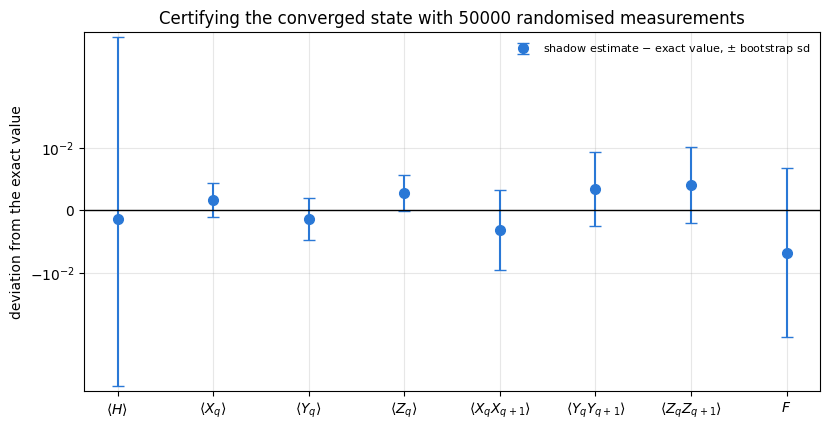

In [13]:
# ==============================================================================
# STEP 10: energy, correlators and fidelity of the converged state, with bootstrap errors
# ==============================================================================
M_FINAL = 50000
psi_final = psi_vqe                                   # the variational state of Section 5
print(f"state to certify: the best of the {R_ANS} exact-gradient VQE restarts of Section 5, N={N_SITES}")
print(f"  exact E = {float(energy(terms, psi_final)):.6f}  (E - E_0 = {float(energy(terms, psi_final)) - E0:.2e}), "
      f"exact F = {float(fidelity_pure(psi_exact, psi_final)):.5f}")

t0 = time.perf_counter()
bases_f, bits_f = collect_shadows(jax.random.PRNGKey(77), psi_final, M_FINAL)
print(f"collected {M_FINAL} verification snapshots in {time.perf_counter() - t0:.1f} s")

# --- the energy and the six panel observables ----------------------------------------------------
vals_H = snapshot_values(bases_f, bits_f, DIGITS) @ jnp.asarray(COEFFS)
vals_panel = snapshot_values(bases_f, bits_f, panel_dig)
rows_final = [("energy <H>", float(energy(terms, psi_final)), np.asarray(vals_H)[:, None])]

for kind in ("<X>", "<Y>", "<Z>", "<XX>", "<YY>", "<ZZ>"):
    sel = groups_panel[kind]
    exact_kind = float(np.mean([expect_label(psi_final, panel_labels[i]) for i in sel]))
    rows_final.append((kind, exact_kind, np.asarray(vals_panel[:, jnp.asarray(sel)]).mean(axis=1)[:, None]))


# --- the fidelity with the exact ground state, from the same snapshots ---------------------------
SNAP1 = jnp.stack([jnp.stack([3.0 * jnp.outer(ROTS[b].conj().T[:, s], ROTS[b].conj().T[:, s].conj()) - I2
                              for s in range(2)]) for b in range(3)])          # (3, 2, 2, 2)


def shadow_fidelity_local(bases, bits, psi_t, chunk=20000):
    """Single-snapshot estimates of <psi_t| rho |psi_t> from Pauli shadows (notebook 24, Step 6).

    MATH   o_m = <psi_t| (x)_q A_q^{(m)} |psi_t>,  A_q = 3 U^dag|b><b|U - 1 = SNAP1[basis, bit]
    IMPL   N apply_gate einsums and one inner product per snapshot; vmap over snapshots, in chunks.
    """
    N = psi_t.ndim

    def one(bb, ss):
        phi = psi_t
        for q in range(N):
            phi = apply_gate(phi, SNAP1[bb[q], ss[q]], [q])
        return jnp.real(jnp.vdot(psi_t, phi))

    f = jax.jit(jax.vmap(one))
    out, done = [], 0
    while done < bases.shape[0]:
        c = min(chunk, bases.shape[0] - done)
        out.append(f(bases[done:done + c], bits[done:done + c]))
        done += c
    return jnp.concatenate(out)


vals_F = shadow_fidelity_local(bases_f, bits_f, psi_exact)
rows_final.append(("fidelity with the GS", float(fidelity_pure(psi_exact, psi_final)),
                   np.asarray(vals_F)[:, None]))

print(f"\n{'quantity':>22s} {'exact':>10s} {'shadow estimate':>18s} {'bootstrap sd':>13s} "
      f"{'median of means':>16s} {'deviation':>12s}")
for name, ex, per_snap in rows_final:
    est = per_snap.mean()
    sem = per_snap.std() / np.sqrt(per_snap.shape[0])
    boot = float(bootstrap_std(jax.random.PRNGKey(78), jnp.asarray(per_snap), N_BOOT)[0])
    mom = float(median_of_means(jnp.asarray(per_snap), 9)[0])
    print(f"{name:>22s} {ex:+10.4f} {est:+12.4f} +- {sem:.4f} {boot:13.4f} {mom:+16.4f} "
          f"{(est - ex) / sem:+9.2f} sd")

def fidelity_second_moment_exact(psi, psi_t):
    """Exact E[f] and E[f^2] of the local-shadow fidelity estimator of <psi_t|rho|psi_t>, rho = |psi><psi|.

    MATH   f(b, s) = sum_x |<x|U_b|psi_t>|^2 prod_q (3 delta(x_q, s_q) - 1),   p(b, s) = 3^-N |<s|U_b|psi>|^2
    IMPL   enumerate the 3^N basis choices; the kernel prod_q (3 delta - 1) is applied as the 2x2 matrix
           [[2, -1], [-1, 2]] on every axis of the probability tensor of U_b psi_t.   COST O(3^N N 2^N).
    """
    N = psi.ndim
    rots = [np.asarray(_BASIS_ROT[c]) for c in "XYZ"]
    kern = np.array([[2.0, -1.0], [-1.0, 2.0]])

    def on_axes(mats, t):
        for q, m in enumerate(mats):
            t = np.moveaxis(np.tensordot(m, t, axes=([1], [q])), 0, q)
        return t

    m1 = m2 = 0.0
    for b in itertools.product(range(3), repeat=N):
        U = [rots[c] for c in b]
        p = np.abs(on_axes(U, np.asarray(psi))) ** 2
        f = on_axes([kern] * N, np.abs(on_axes(U, np.asarray(psi_t))) ** 2)
        m1 += np.sum(p * f) / 3 ** N
        m2 += np.sum(p * f ** 2) / 3 ** N
    return m1, m2


f1_ex, f2_ex = fidelity_second_moment_exact(psi_final, psi_exact)
m2_meas, m2_se = float(jnp.mean(vals_F ** 2)), float(jnp.std(vals_F ** 2)) / np.sqrt(M_FINAL)
print(f"\nCHECKPOINT fidelity estimator: exact E[f] = {f1_ex:.6f} (= F, unbiased), "
      f"second moment measured {m2_meas:.2f} +- {m2_se:.2f} vs exact {f2_ex:.2f} "
      f"(z = {(m2_meas - f2_ex) / m2_se:+.2f}); product-state value (3/2)^N = {1.5 ** N_SITES:.2f}")
assert abs(f1_ex - float(fidelity_pure(psi_exact, psi_final))) < 1e-10 and abs(m2_meas - f2_ex) < 4 * m2_se
v_H, se_H = var_and_se(np.asarray(vals_H))
print(f"CHECKPOINT single-snapshot variance of the energy estimator: {v_H:.2f} +- {se_H:.2f}, "
      f"Eqs. (7) and (8) predict {var_shadow:.2f} (z = {(v_H - var_shadow) / se_H:+.2f})")
assert abs(v_H - var_shadow) < 4 * se_H
boot_ratio = [float(bootstrap_std(jax.random.PRNGKey(78), jnp.asarray(r[2]), N_BOOT)[0])
              / (r[2].std() / np.sqrt(r[2].shape[0])) for r in rows_final]
print(f"bootstrap sd / analytic sd over the eight rows: {min(boot_ratio):.3f} ... {max(boot_ratio):.3f} "
      f"(Monte-Carlo resolution of {N_BOOT} resamples: +-{1 / np.sqrt(2 * (N_BOOT - 1)):.3f})")

fig, ax = plt.subplots(figsize=(8.4, 4.4))
names = [r[0] for r in rows_final]
ex_v = np.array([r[1] for r in rows_final])
est_v = np.array([r[2].mean() for r in rows_final])
err_v = np.array([float(bootstrap_std(jax.random.PRNGKey(79), jnp.asarray(r[2]), N_BOOT)[0]) for r in rows_final])
xs = np.arange(len(names))
# the quantities live on very different scales, so plot the deviation from the exact value
ax.errorbar(xs, est_v - ex_v, yerr=err_v, fmt="o", ms=7, color=PALETTE[0], capsize=4,
            label=r"shadow estimate $-$ exact value, $\pm$ bootstrap sd")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(xs)
TICKS = {"energy <H>": r"$\langle H\rangle$", "fidelity with the GS": r"$F$"}
ax.set_xticklabels([TICKS.get(nm, KIND_TEX.get(nm, nm)) for nm in names])
ax.set_yscale("symlog", linthresh=0.02)
ax.set_ylabel("deviation from the exact value")
ax.set_title(f"Certifying the converged state with {M_FINAL} randomised measurements")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Every estimate agrees with its exact value, and the error bars are correct.** All eight reported quantities lie
within $0.9$ standard errors of their exact values: the energy $-11.186\pm0.057$ against $-11.185$, the six averaged
observables, and the fidelity with the exact ground state $0.992\pm0.014$ against $0.9990$. The bootstrap standard
deviations agree with the analytic $\sigma/\sqrt M$ to within $8\%$, at most $1.6$ times the $\pm5\%$ Monte-Carlo
resolution of $200$ resamples, which is the expected behaviour for sample means.

**Equation (8) again.** On the six-qubit state the single-snapshot variance of the energy estimator is
$161.56\pm1.14$ against $161.38$ predicted ($+0.2$ standard errors), after the $96.63\pm0.63$ against $96.05$ of the
four-site ground state in Section 8 and the $160.28\pm0.78$ of Section 6 (a different data set for the same state).

**The fidelity is the expensive one.** The estimator is unbiased (its exact mean, from the enumeration, equals
$F=0.999044$), and its single-snapshot second moment is $10.95\pm0.62$ measured against $11.33$ exact, close to the
$(3/2)^6=11.39$ of a product target: the state is nearly a product state. That is almost four times the $3$ of a
single-site magnetisation, which is why $5\cdot10^{4}$ snapshots give the fidelity an error bar of $0.014$ while the
same data determine $\langle X\rangle$ to $0.003$. For a product target the second moment grows as $(3/2)^N$, so at
$N=20$ it would be $3.3\cdot10^{3}$ and the same budget would leave an error bar of about $0.26$; certifying
twenty-qubit states needs either far more snapshots or global (Clifford) shadows.

**What the whole pipeline delivered.** A circuit was trained, and then a single data set of integers — $2\times
5\cdot10^{4}\times6$ numbers, no amplitudes, no density matrix — was enough to report its energy, its magnetisation
profile, its bond correlators and its overlap with the target, each with an error bar, each agreeing with the exact
answer.

## 12. Key takeaways

* **A local Hamiltonian is a sum of $T=4N-3$ Pauli strings, but it needs only $G=3$ measurement settings.** The
  lower bound follows from one bond needing the three assignments $(X,X)$, $(Y,Y)$, $(Z,Z)$; the upper bound from
  measuring every qubit in $X$, then $Y$, then $Z$. The setting count is **independent of $N$** while the term count
  is not.
* **Three estimator variances, derived and then measured.** At a fixed budget $S$, Eqs. (5), (6) and (7)-(8) predict
  $S\,\mathrm{Var}=136.7$, $22.7$ and $161.4$ for term-by-term, grouped and shadow estimation of this chain's energy.
  The per-shot variances pooled over $10^{5}$ shots per protocol reproduce them within $1.4$ standard errors, and the
  covariance-free versions of the grouped and shadow formulas are rejected by $18$ and $67$ standard errors.
* **For a fixed known Hamiltonian, grouping wins by a wide margin**: $2.3\cdot10^{5}$ shots for a standard error of
  $10^{-2}$ against $1.4\cdot10^{6}$ (term by term) and $1.6\cdot10^{6}$ (shadows). With the optimal shot allocation
  of Eqs. (5a) and (6a) the advantage over term by term is $4.4$ instead of $6.0$.
* **Covariances between terms measured in the same shot can dominate a setting.** In the all-$X$ setting the eleven
  individual variances add up to $0.40$ and the covariances to $1.03$, because a flipped spin changes a field term
  and two bond terms together; overall they make grouping $16\%$ worse than counting suggests. For shadows the
  covariances of Eq. (8), $\mathrm{Cov}=3^{\lvert I\rvert}\langle P_tP_{t'}\rangle-\langle P_t\rangle\langle P_{t'}\rangle$,
  add half of the diagonal part, and the full formula matched the measured single-snapshot variance on two states.
* **The measurement cost depends on the state.** The all-$X$ setting carries eleven of the twenty-one terms and
  contributes $1.43$ of the grouped variance, while the all-$Y$ setting carries five terms and contributes $4.97$.
* **For a single Pauli string shadows are never cheaper than a setting that contains it; they are adaptive.**
  Equation (9) gives the variance ratio $(3^k-\langle P\rangle^2)/(3(1-\langle P\rangle^2))\ge1$. For the averaged
  panel observables, with covariances included, the standard-error ratio ranged from $0.92$ ($\langle Y\rangle$,
  positively correlated sites) to $8.0$ ($\langle XX\rangle$, nearly deterministic strings). All $33$ strings came
  from one data set collected before any of them was named.
* **Inside the loop, the snapshot budget per iteration sets the achievable error through the cost noise.** With the
  step size re-tuned for the noisy cost, the median final errors were $1.01\pm0.34$, $0.337\pm0.029$ and
  $0.172\pm0.012$ at $M=64$, $256$ and $1024$ snapshots per cost evaluation, against cost noise of $1.23$, $0.61$ and
  $0.31$: accuracy improves roughly as $M^{-1/2}$.
* **Separate the contributions before blaming the circuit.** With $10^{6}$ snapshots the shadow-driven run reached
  $0.17$; the same optimiser with an exact cost $0.052$; exact gradients at a constant Adam step $0.0065$; the same
  runs continued at a smaller step $7.8\cdot10^{-4}$, an upper bound on the ansatz error. A constant-step plateau belongs to
  the optimiser.
* **A cost estimated from few measurements is unbiased, and the *minimum* of several such costs is biased low.** Selecting the
  lowest of six noisy estimates reported energies $1.33$, $0.77$ and $0.38$ below the truth at $M=64$, $256$, $1024$,
  as the Gaussian model of Eq. (11) predicts (in the equal-cost limit $-e_R\sigma/\sqrt M$, $e_6=1.27$), and below the
  exact ground energy in most repetitions. Select with the noisy data, report with fresh data.
* **One data set of integers certifies the whole state.** $5\cdot10^{4}$ randomised measurements gave the energy,
  six averaged observables and the fidelity with the exact ground state, all within $0.9$ standard errors, with
  bootstrap error bars that reproduced the analytic ones. The fidelity was the expensive entry, with an exact
  single-snapshot second moment of $11.33$ against $3$ for a magnetisation, growing like $(3/2)^N$ for near-product
  targets.

## 13. Exercises

1. ★ **The Ising count.** Repeat the derivation of Section 3.3 for the transverse-field Ising chain and for the
   Heisenberg chain with a longitudinal field $h_z\sum_qZ_q$. Give the minimal number of qubit-wise-commuting
   settings for each and say which terms are read from the same setting as the bond terms.
2. ★ **Accuracy for a price.** Using the variances of Section 6, compute how many shots each of the three strategies
   needs for a standard error of $10^{-3}$ on the energy of this chain. Then evaluate Eqs. (5)-(8) on the exact
   ground states at $N=6$ and $N=12$ (Lanczos) and check which of the three $S\,\mathrm{Var}$ grow like $N$ and which
   faster; explain the exception from the factor $T$ in Eq. (5).
3. ★★ **The covariance formula (extend the code).** Verify Eq. (8) directly: for the overlapping bond terms
   $X_0X_1$ and $X_1X_2$, collect shadows of the state of Section 5 and compare the measured
   $\mathbb E[\hat o_t\hat o_{t'}]$ with $3^{\lvert I\rvert}\langle P_tP_{t'}\rangle=3\langle X_0X_2\rangle$. Then repeat
   for $Y_0Y_1$ and $X_1X_2$, which disagree on qubit $1$, and confirm that the product is identically zero.
4. ★★ **Locally biased shadows (extend the code).** Replace the uniform basis distribution by a distribution
   $\beta=(\beta_X,\beta_Y,\beta_Z)$, the same on every qubit, and re-derive the estimator: the factor $3$ per qubit
   in Eq. (4) becomes $1/\beta_{\sigma_q}$, and in Eq. (8) $3^{\lvert I\rvert}$ becomes $\prod_{q\in I}1/\beta_{\sigma_q}$.
   Minimise the single-snapshot energy variance over $\beta$ for the state of Section 5 (hint: the $X$ terms
   outnumber the others) and compare with the uniform $161.4$.
5. ★★ **Shots per iteration versus iterations (physics).** Section 8 fixed the iteration count and varied $M$. Fix
   the *total* snapshot budget $2MT$ instead (for example $2.56\cdot10^{5}$ and $1.02\cdot10^{6}$), trade $M$ against
   the number of iterations $T$, and re-tune the step size for each pair. Where is the optimum, and does it move as
   the budget grows?
6. ★★ **Median of means in the loop.** Replace the sample mean of the shadow cost by a median of means with $9$
   groups and repeat Section 8 at $M=256$ (with its own step-size scan). Compare first the standard deviation of a
   single cost estimate of the two estimators on the ground state, then the final errors.
7. ★★★ **Quantifying the winner's curse (physics).** For one fixed state (equal true costs), draw many independent
   shadow estimates of the energy, group them into sets of $R$, and measure $\mathbb E[\min_i\hat C_i]-C$ for
   $R=2,6,20$ and $M=64,256$. Compare with Eq. (11), $-e_R\sigma/\sqrt M$, and with its large-$R$ form
   $-\sigma\sqrt{2\ln R}/\sqrt M$. Where does the asymptotic form fail?
8. ★★★ **A shadow-based gradient (extend the code).** Instead of estimating the cost and applying SPSA, estimate the
   parameter-shift gradient from shadows: each of the $2n$ shifted circuits needs its own data set. Derive the total
   snapshot cost per iteration, implement it (check it against `jax.grad` on the exact cost first), and compare with
   SPSA at an equal total budget of $2.56\cdot10^{5}$ snapshots, each method at its own best step size and $M$.

## 14. References

* H.-Y. Huang, R. Kueng and J. Preskill, *Predicting many properties of a quantum system from very few measurements*,
  Nat. Phys. **16**, 1050 (2020) — classical shadows, the estimator of Eq. (4) and its variance.
* H.-Y. Huang, R. Kueng and J. Preskill, *Efficient estimation of Pauli observables by derandomization*,
  Phys. Rev. Lett. **127**, 030503 (2021) — the derandomised schedule of Section 10.
* C. Hadfield, S. Bravyi, R. Raymond and A. Mezzacapo, *Measurements of quantum Hamiltonians with locally-biased
  classical shadows*, Commun. Math. Phys. **391**, 951 (2022) — biased local ensembles.
* V. Verteletskyi, T.-C. Yen and A. F. Izmaylov, *Measurement optimization in the variational quantum eigensolver
  using a minimum clique cover*, J. Chem. Phys. **152**, 124114 (2020) — grouping commuting terms as a graph-colouring
  problem.
* A. Peruzzo, J. McClean, P. Shadbolt, M.-H. Yung, X.-Q. Zhou, P. J. Love, A. Aspuru-Guzik and J. L. O'Brien,
  *A variational eigenvalue solver on a photonic quantum processor*, Nat. Commun. **5**, 4213 (2014) — the first VQE
  experiment, and the term-by-term measurement scheme of Section 3.2.
* J. Tilly, H. Chen, S. Cao, D. Picozzi, K. Setia, Y. Li, E. Grant, L. Wossnig, I. Rungger, G. H. Booth and
  J. Tennyson, *The variational quantum eigensolver: a review of methods and best practices*, Phys. Rep. **986**, 1
  (2022) — the measurement problem in context, with cost estimates for molecular Hamiltonians.
* J. C. Spall, *Multivariate stochastic approximation using a simultaneous perturbation gradient approximation*,
  IEEE Trans. Autom. Control **37**, 332 (1992) — the SPSA gradient rule used in Section 8.
* M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan,
  L. Cincio and P. J. Coles, *Variational quantum algorithms*, Nat. Rev. Phys. **3**, 625 (2021) — the review, with a
  section on measurement cost.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/